In [ ]:
import platform

# Get the name of the operating system
system_name = platform.system()

import pandas as pd
import os
from FCA.helpers.dep2pyodbc import dep2connection
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
con = dep2connection("CRH_DWH")

pyodbc using linux/docker


In [3]:
def filter_on_column(df, column, value):
    return df[df[column] == value]

- Datacleaning
- Prepare
- Modelselection
  - KNN
  - Embedding

In [4]:
df_test = pd.read_sql("SELECT FCATestKey, CandidateKey, CreatedDateKey, ModifiedDateKey, PostedDateKey, TestStartTimeKey, TestFinishTimeKey, AnomaliesKey, VersionNumber FROM FactTestFCA", con)
df_test["CreatedDateKey"] = pd.to_datetime(df_test["CreatedDateKey"], format="%Y%m%d")
df_question = pd.read_sql("SELECT * FROM FactQuestionFCA", con)
# df_test.drop(columns=["HexadecimaleString"], inplace=True)

/tmp/ipykernel_57775/905536295.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_test = pd.read_sql("SELECT FCATestKey, CandidateKey, CreatedDateKey, ModifiedDateKey, PostedDateKey, TestStartTimeKey, TestFinishTimeKey, AnomaliesKey, VersionNumber FROM FactTestFCA", con)
/tmp/ipykernel_57775/905536295.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_question = pd.read_sql("SELECT * FROM FactQuestionFCA", con)


In [5]:
df_test.tail()

,FCATestKey,CandidateKey,CreatedDateKey,ModifiedDateKey,PostedDateKey,TestStartTimeKey,TestFinishTimeKey,AnomaliesKey,VersionNumber
160062,160063,49206841,2023-10-31,20231031,20231031,104057,110911,0,v1.0
160063,160064,49208481,2023-10-27,20231027,20231027,123533,130252,0,v1.0
160064,160065,49209181,2023-11-15,20231115,20231115,73708,80636,0,v1.0
160065,160066,49210931,2023-11-14,20231114,20231114,73921,80421,0,v1.0
160066,160067,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0


In [6]:
df_question.tail()

,FCAQuestionKey,FCATestKey,Competence1Key,Competence2Key,Competence3Key,Competence4Key,AnomaliesKey,ItemID,AnswerSequence1,AnswerSequence2,AnswerSequence3,TimeSpent
3035700,3035701,160067,68,541,0,0,0,422,4,5,2,80.0
3035701,3035702,160067,69,0,0,0,0,423,5,3,4,98.0
3035702,3035703,160067,70,0,0,0,0,424,1,2,5,126.0
3035703,3035704,160067,71,0,0,0,0,425,5,4,1,443.0
3035704,3035705,160067,72,0,0,0,0,426,3,5,2,37.0


We see no values for Competence4Key so we drop it later.

In [7]:
df_question.describe()

,FCAQuestionKey,FCATestKey,Competence1Key,Competence2Key,Competence3Key,Competence4Key,AnomaliesKey,ItemID,AnswerSequence1,AnswerSequence2,AnswerSequence3,TimeSpent
count,3.035705e+06,3.035705e+06,3.035705e+06,3.035705e+06,3.035705e+06,3035705.0,3.035705e+06,3.035705e+06,3.035705e+06,3.035705e+06,3.035705e+06,3.035705e+06
mean,1.517853e+06,7.947524e+04,5.455131e+01,1.039406e+02,1.393139e+01,0.0,1.558392e+00,3.049683e+02,3.271753e+00,3.227965e+00,3.449082e+00,1.802217e+02
std,8.763327e+05,4.593931e+04,6.264589e+01,1.958561e+02,1.071589e+02,0.0,1.386835e+02,9.079508e+01,1.450368e+00,1.422955e+00,1.427246e+00,4.684064e+02
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,1.170000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.589270e+05,3.977300e+04,2.900000e+01,0.000000e+00,0.000000e+00,0.0,0.000000e+00,2.290000e+02,2.000000e+00,2.000000e+00,2.000000e+00,5.700000e+01
50%,1.517853e+06,7.924000e+04,4.100000e+01,0.000000e+00,0.000000e+00,0.0,0.000000e+00,2.380000e+02,3.000000e+00,3.000000e+00,4.000000e+00,1.000000e+02
75%,2.276779e+06,1.187020e+05,5.100000e+01,1.830000e+02,0.000000e+00,0.0,0.000000e+00,4.130000e+02,5.000000e+00,4.000000e+00,5.000000e+00,1.760000e+02
max,3.035705e+06,1.600670e+05,4.960000e+02,8.190000e+02,9.370000e+02,0.0,1.972500e+04,4.470000e+02,5.000000e+00,5.000000e+00,5.000000e+00,1.638300e+04


There are no Competence4Keys

In [8]:
df_question[["Competence1Key", "Competence2Key", "Competence3Key", "Competence4Key"]].astype(bool).sum(axis=0)

Competence1Key    3035705
Competence2Key     844231
Competence3Key      51008
Competence4Key          0
dtype: int64

v2.0 seems not to be in use anymore

In [9]:
df_test["VersionNumber"].value_counts()

VersionNumber
v1.0    141036
V1.0     18792
v2.0       239
Name: count, dtype: int64

In [10]:
filter_on_column(df_test, "VersionNumber", "v1.0").sort_values("CreatedDateKey")

,FCATestKey,CandidateKey,CreatedDateKey,ModifiedDateKey,PostedDateKey,TestStartTimeKey,TestFinishTimeKey,AnomaliesKey,VersionNumber
523,524,5510691,2011-01-21,20110121,20191121,122224,132224,524,v1.0
508,509,5506861,2011-01-21,20110121,20191121,92949,102949,509,v1.0
509,510,5544811,2011-01-24,20110124,20191121,92449,102449,510,v1.0
894,895,5545181,2011-01-24,20110124,20191121,94752,104752,895,v1.0
885,886,5547031,2011-01-24,20110124,20191121,115902,125902,886,v1.0
...,...,...,...,...,...,...,...,...,...
142412,142413,50832111,2024-09-19,20240923,20240923,81123,124749,0,v1.0
142421,142422,50832131,2024-09-19,20240919,20240919,112143,113458,0,v1.0
142385,142386,50832121,2024-09-19,20240919,20240919,105732,111551,0,v1.0
142367,142368,50832091,2024-09-19,20240923,20240923,85745,131810,0,v1.0


In [11]:
filter_on_column(df_test, "VersionNumber", "V1.0").sort_values("CreatedDateKey")

,FCATestKey,CandidateKey,CreatedDateKey,ModifiedDateKey,PostedDateKey,TestStartTimeKey,TestFinishTimeKey,AnomaliesKey,VersionNumber
122399,122400,18068231,2013-01-13,20130113,20191121,105223,115223,0,V1.0
22327,22328,19224421,2013-02-13,20130213,20191121,83402,93402,0,V1.0
27509,27510,19224621,2013-02-13,20130213,20191121,113957,123957,0,V1.0
26151,26152,19224561,2013-02-13,20130213,20191121,114240,124240,0,V1.0
23953,23954,18866031,2013-02-15,20130215,20191121,92829,102829,0,V1.0
...,...,...,...,...,...,...,...,...,...
38791,38792,126112,2024-09-02,20240902,20240902,130145,130324,0,V1.0
70197,70198,45646985,2024-09-02,20240902,20240902,124657,124908,0,V1.0
62885,62886,3870973,2024-09-02,20240902,20240902,133407,133559,0,V1.0
504,505,50084,2024-09-02,20240902,20240902,140645,140830,505,V1.0


In [12]:
filter_on_column(df_test, "VersionNumber", "v2.0").sort_values("CreatedDateKey")

,FCATestKey,CandidateKey,CreatedDateKey,ModifiedDateKey,PostedDateKey,TestStartTimeKey,TestFinishTimeKey,AnomaliesKey,VersionNumber
128236,128237,30078581,2015-01-07,20150107,20191121,202719,202851,0,v2.0
20915,20916,30151291,2015-01-22,20150122,20191121,122636,122742,0,v2.0
29288,29289,30156161,2015-01-22,20150122,20191121,81639,81732,0,v2.0
22796,22797,30151211,2015-01-22,20150123,20191121,81505,90059,0,v2.0
31642,31643,30156131,2015-01-22,20150123,20191121,81308,85508,0,v2.0
...,...,...,...,...,...,...,...,...,...
65044,65045,39259061,2019-06-28,20190628,20191121,75608,81253,0,v2.0
51028,51029,39259051,2019-06-28,20190628,20191121,73100,81509,0,v2.0
147561,147562,39259131,2019-06-28,20190628,20191121,74251,80857,0,v2.0
101989,101990,41421901,2020-06-08,20200915,20200915,105214,90032,0,v2.0


In [13]:
df_merged = pd.merge(df_question, df_test, how="left", on=["FCATestKey"])
df_merged.drop(columns="Competence4Key", inplace=True)
df_merged

,FCAQuestionKey,FCATestKey,Competence1Key,Competence2Key,Competence3Key,AnomaliesKey_x,ItemID,AnswerSequence1,AnswerSequence2,AnswerSequence3,TimeSpent,CandidateKey,CreatedDateKey,ModifiedDateKey,PostedDateKey,TestStartTimeKey,TestFinishTimeKey,AnomaliesKey_y,VersionNumber
0,1,1,1,0,0,0,222,0,0,0,11.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0
1,2,1,2,183,0,0,223,3,4,2,3.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0
2,3,1,3,184,0,0,226,4,3,2,13.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0
3,4,1,4,0,0,0,229,2,0,4,100.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0
4,5,1,5,0,0,0,238,0,0,0,2.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035700,3035701,160067,68,541,0,0,422,4,5,2,80.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0
3035701,3035702,160067,69,0,0,0,423,5,3,4,98.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0
3035702,3035703,160067,70,0,0,0,424,1,2,5,126.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0
3035703,3035704,160067,71,0,0,0,425,5,4,1,443.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0


In [14]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035705 entries, 0 to 3035704
Data columns (total 19 columns):
 #   Column             Dtype         
---  ------             -----         
 0   FCAQuestionKey     int64         
 1   FCATestKey         int64         
 2   Competence1Key     int64         
 3   Competence2Key     int64         
 4   Competence3Key     int64         
 5   AnomaliesKey_x     int64         
 6   ItemID             int64         
 7   AnswerSequence1    int64         
 8   AnswerSequence2    int64         
 9   AnswerSequence3    int64         
 10  TimeSpent          float64       
 11  CandidateKey       int64         
 12  CreatedDateKey     datetime64[ns]
 13  ModifiedDateKey    int64         
 14  PostedDateKey      int64         
 15  TestStartTimeKey   int64         
 16  TestFinishTimeKey  int64         
 17  AnomaliesKey_y     int64         
 18  VersionNumber      object        
dtypes: datetime64[ns](1), float64(1), int64(16), object(1)
memory u

In [15]:
df_grouped = (df_merged[["FCAQuestionKey", "FCATestKey", "CreatedDateKey"]].groupby(["CreatedDateKey"]).nunique())
df_grouped

,FCAQuestionKey,FCATestKey
CreatedDateKey,,
2011-01-21,27,2
2011-01-24,26,3
2011-01-25,18,1
2011-01-26,1946,110
2012-03-03,2,1
...,...,...
2024-09-16,16,1
2024-09-17,23,2
2024-09-18,38,2


In [16]:
series_avg_questions_per_test_over_time = (df_grouped["FCAQuestionKey"] / df_grouped["FCATestKey"])
series_avg_questions_per_test_over_time

CreatedDateKey
2011-01-21    13.500000
2011-01-24     8.666667
2011-01-25    18.000000
2011-01-26    17.690909
2012-03-03     2.000000
                ...    
2024-09-16    16.000000
2024-09-17    11.500000
2024-09-18    19.000000
2024-09-19    19.400000
2024-09-20     8.000000
Length: 3809, dtype: float64

In [17]:
series_avg_questions_per_test_over_time.index = pd.to_datetime(series_avg_questions_per_test_over_time.index, format="%Y%m%d")

In [18]:
series_avg_questions_per_test_over_time.index

DatetimeIndex(['2011-01-21', '2011-01-24', '2011-01-25', '2011-01-26',
               '2012-03-03', '2012-03-04', '2012-03-05', '2012-03-06',
               '2012-03-08', '2013-01-13',
               ...
               '2024-07-24', '2024-07-29', '2024-08-27', '2024-08-29',
               '2024-09-02', '2024-09-16', '2024-09-17', '2024-09-18',
               '2024-09-19', '2024-09-20'],
              dtype='datetime64[ns]', name='CreatedDateKey', length=3809, freq=None)

<Axes: xlabel='CreatedDateKey'>

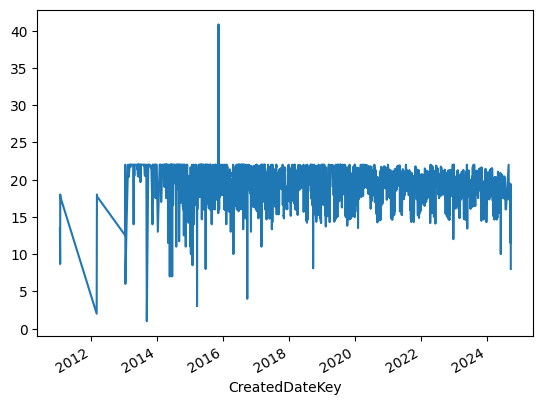

In [19]:
series_avg_questions_per_test_over_time.plot()

<Axes: xlabel='CreatedDateKey'>

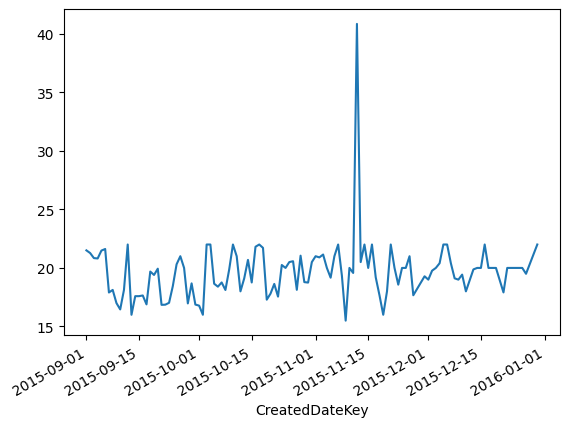

In [20]:
series_avg_questions_per_test_over_time.loc['2015-9-1':'2016-1-1'].plot()

<Axes: xlabel='CreatedDateKey'>

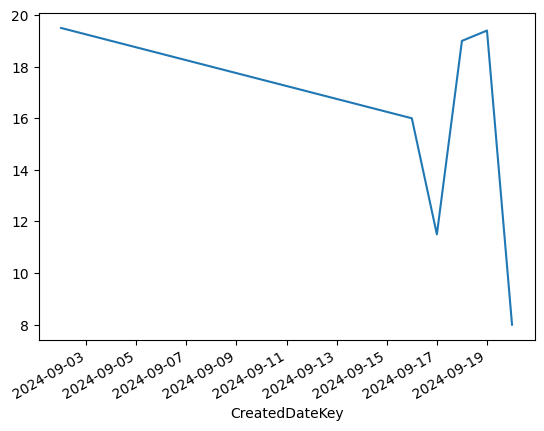

In [21]:
series_avg_questions_per_test_over_time.loc['2024-9-1':].plot()

In [22]:
df_merged[["CreatedDateKey", "ItemID", "FCAQuestionKey"]].groupby(["CreatedDateKey", "ItemID"]).count()

FCAQuestionKey
CreatedDateKey ItemID                
2011-01-21     117                  2
               118                  2
               119                  2
               120                  2
               121                  2
...                               ...
2024-09-20     411                  1
               412                  1
               414                  1
               417                  1
               418                  1

[161227 rows x 1 columns]

In [23]:
df_merged["month"] = df_merged["CreatedDateKey"].dt.month
df_merged["year"] = df_merged["CreatedDateKey"].dt.year

In [24]:
pivot_df = df_merged.pivot_table(
    index=['year', 'month'],
    columns='ItemID',
    values='FCAQuestionKey',
    aggfunc='count',
    fill_value=0  # Fill missing values with 0
)

In [25]:
pivot_df

ItemID      117  118  119  120  121  122  123  124  125  126  127  128  129  \
year month                                                                    
2011 1      116  116  116  115  114  114  114  113  112  112  112  111  111   
2012 3        0    0    0    0    0    0    0    0    0    0    0    0    0   
2013 1        0    0    0    0    0    0    0    0    0    0    0    0    0   
     2        0    0    0    0    0    0    0    0    0    0    0    0    0   
     3        0    0    0    0    0    0    0    0    0    0    0    0    0   
...         ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
2024 5        0    0    0    0    0    0    0    0    0    0    0    0    0   
     6        0    0    0    0    0    0    0    0    0    0    0    0    0   
     7        0    0    0    0    0    0    0    0    0    0    0    0    0   
     8        0    0    0    0    0    0    0    0    0    0    0    0    0   
     9        0    0    0    0    0    0    0    0    0    0    0    0    0   

ItemID      130  131  132  133  134  201  202  203  204  205  206  207  208  \
year month                                                                    
2011 1      111  109  109  107  105    0    0    0    0    0    0    0    0   
2012 3        0    0    0    0    0  123  122  122  122  122  122  121  121   
2013 1        0    0    0    0    0    0    0    0    0    0    0    0    0   
     2        0    0    0    0    0    0    0    0    0    0    0    0    0   
     3        0    0    0    0    0    0    0    0    0    0    0    0    0   
...         ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
2024 5        0    0    0    0    0    0    0    0    0    0    0    0    0   
     6        0    0    0    0    0    0    0    0    0    0    0    0    0   
     7        0    0    0    0    0    0    0    0    0    0    0    0    0   
     8        0    0    0    0    0    0    0    0    0    0    0    0    0   
     9        0    0    0    0    0    0    0    0    0    0    0    0    0   

ItemID      209  210  211  212  213  214  215  216  217  218  220  221  222  \
year month                                                                    
2011 1        0    0    0    0    0    0    0    0    0    0    0    0    0   
2012 3      121  120  120  120  119  118  117  117  115  116    0    0    0   
2013 1        0    0    0    0    0    0    0    0    0    0    3    2    4   
     2        0    0    0    0    0    0    0    0    0    0    7    7    8   
     3        0    0    0    0    0    0    0    0    0    0   46   46   47   
...         ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
2024 5        0    0    0    0    0    0    0    0    0    0  216  215  232   
     6        0    0    0    0    0    0    0    0    0    0  254  254  274   
     7        0    0    0    0    0    0    0    0    0    0  107  108  115   
     8        0    0    0    0    0    0    0    0    0    0    3    3    3   
     9        0    0    0    0    0    0    0    0    0    0    6    6    5   

ItemID      223  224  225  226  227  228  229  230  231  232  233  234  235  \
year month                                                                    
2011 1        0    0    0    0    0    0    0    0    0    0    0    0    0   
2012 3        0    0    0    0    0    0    0    0    0    0    0    0    0   
2013 1        4    4    4    4    2    2    5    2    2    2    3    3    3   
     2        8    8    8    8    7    8    8    8    7    8    8    8    8   
     3       47   47   47   47   46   47   47   47   46   47   47   47   47   
...         ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
2024 5      232  232  232  232  218  229  232  231  217  231  231  229  232   
     6      274  274  274  274  256  274  274  270  255  270  269  269  274   
     7      115  115  115  115  107  113  115  114  108  115  115  114  115   
     8        3    3    3    3    3    3    3  

In [26]:
idx_pivot = pivot_df.index.to_frame().assign(Day=1)
date_index = pd.to_datetime(idx_pivot)

In [27]:
pivot_df.index = date_index

In [28]:
pivot_df

ItemID,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,243,244,245,246,247,248,249,250,251,252,253,254,255,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447
2011-01-01,116,116,116,115,114,114,114,113,112,112,112,111,111,111,109,109,107,105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2012-03-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,122,122,122,122,122,121,121,121,120,120,120,119,118,117,117,115,116,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013-01-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2,4,4,4,4,4,2,2,5,2,2,2,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013-02-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,7,8,8,8,8,8,7,8,8,8,7,8,8,8,8,8,8,7,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013-03-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,46,46,47,47,47,47,47,46,47,47,47,46,47,47,47,47,47,47,47,47,47,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [29]:
pivot_df = pivot_df.div(pivot_df.max(axis=1), axis=0)
pivot_df

ItemID,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,243,244,245,246,247,248,249,250,251,252,253,254,255,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447
2011-01-01,1.0,1.0,1.0,0.991379,0.982759,0.982759,0.982759,0.974138,0.965517,0.965517,0.965517,0.956897,0.956897,0.956897,0.939655,0.939655,0.922414,0.905172,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-03-01,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.99187,0.99187,0.99187,0.99187,0.99187,0.98374,0.98374,0.98374,0.97561,0.97561,0.97561,0.96748,0.95935,0.95122,0.95122,0.934959,0.943089,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2013-01-01,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.600000,0.400000,0.800000,0.800000,0.800000,0.800000,0.800000,0.400000,0.400000,1.000000,0.400000,0.400000,0.400000,0.600000,0.60000

<Axes: >

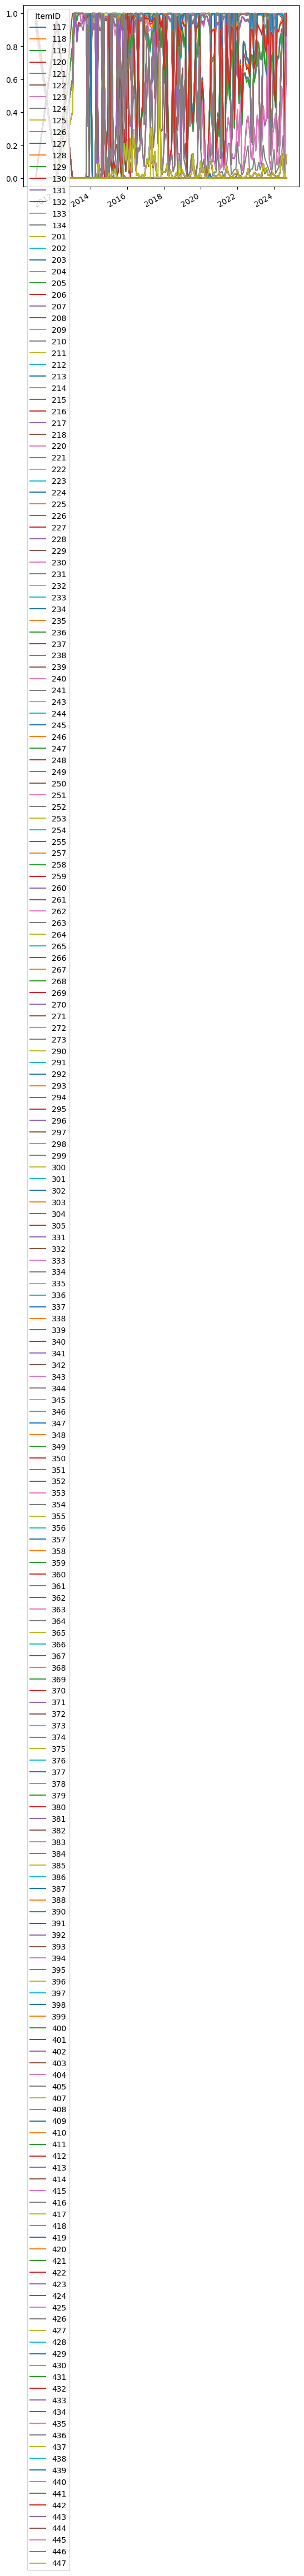

In [30]:
pivot_df.plot()

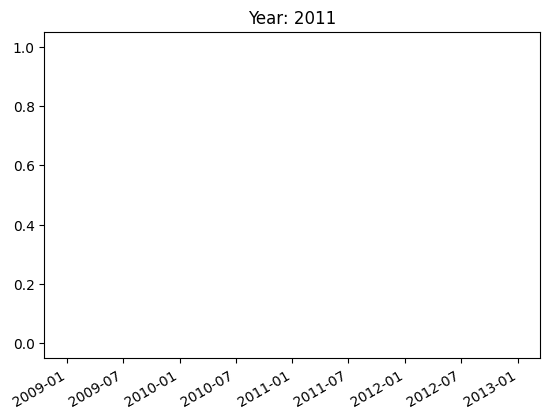

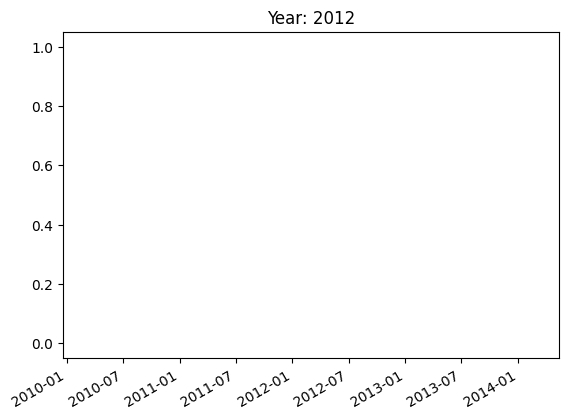

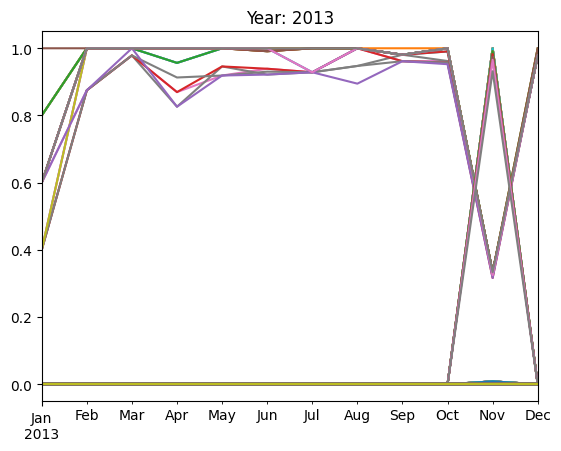

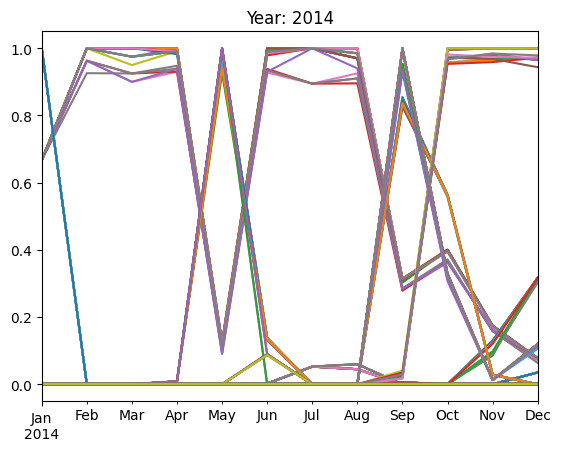

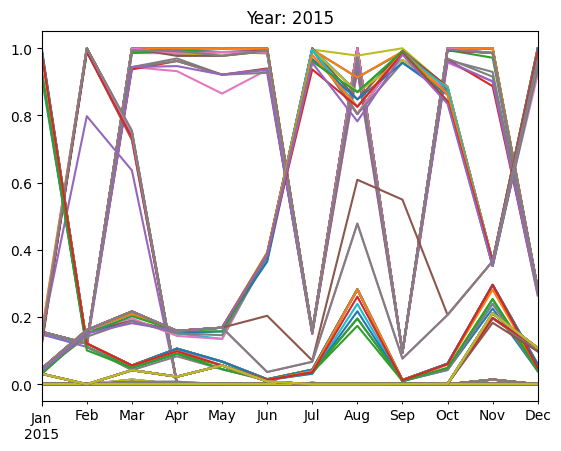

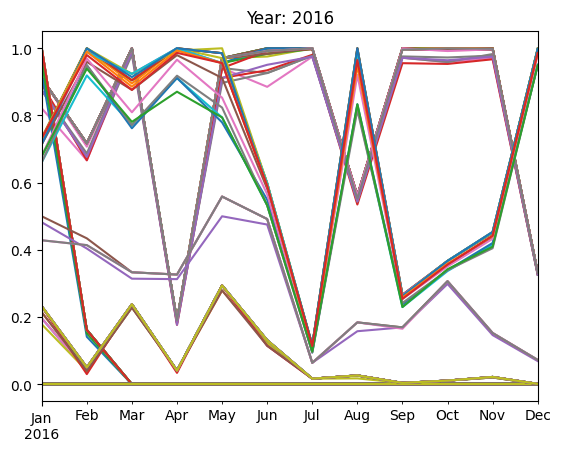

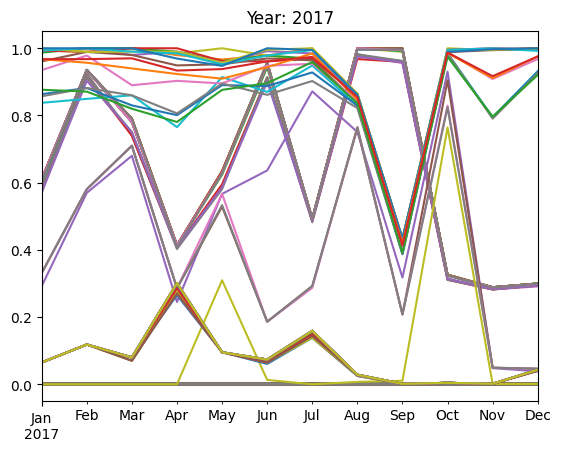

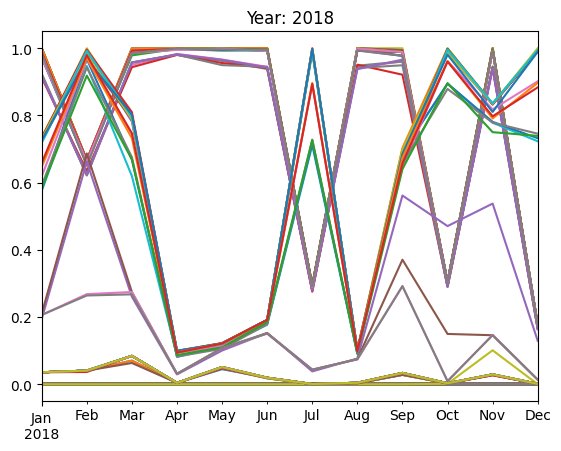

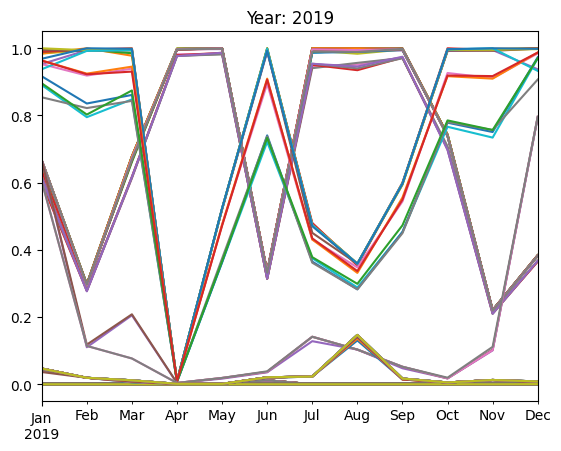

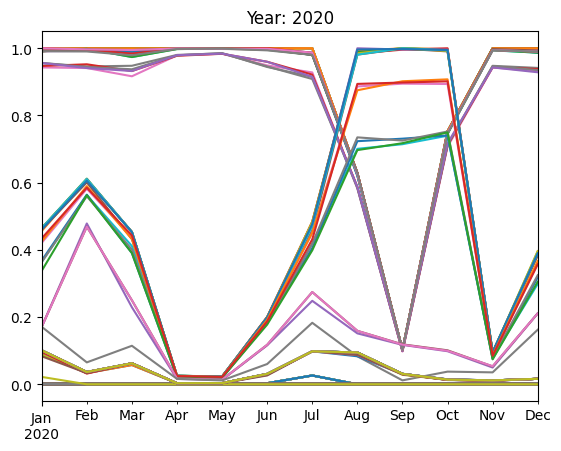

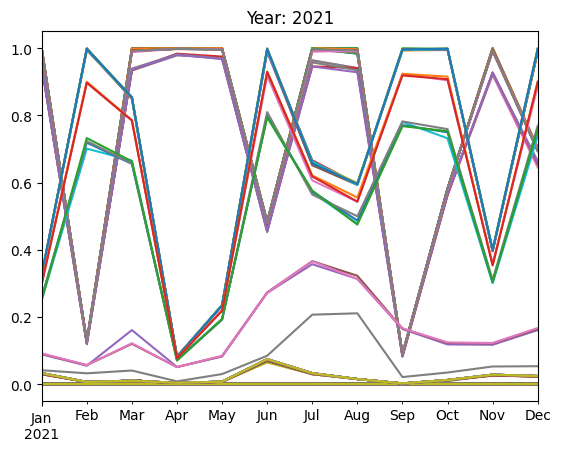

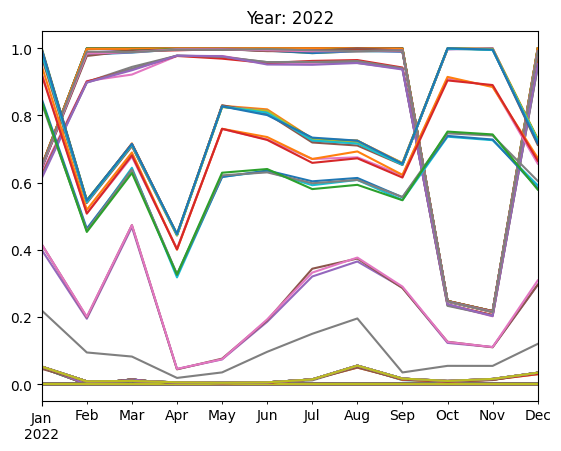

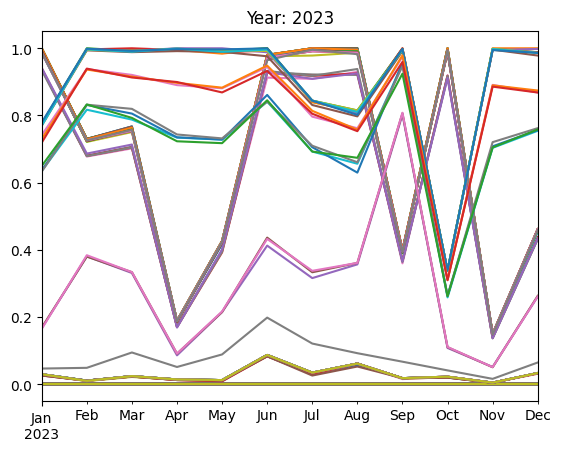

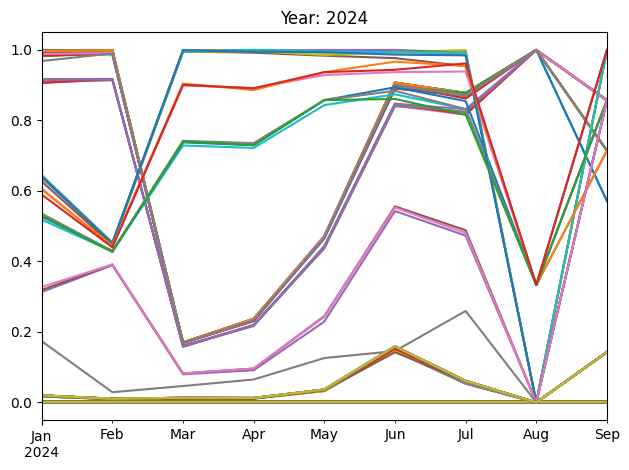

In [31]:
import matplotlib.pyplot as plt

series_year = pivot_df.index.year
years = series_year.unique()

# Create subplots
# fig, axs = plt.subplots(len(years), 1, figsize=(10, 5 * len(years)), sharex=True)


# Plot each year in a separate subplot
for i, year in enumerate(years):
    year_data = pivot_df[series_year == year]
    year_data.plot(legend=False, title=f'Year: {year}')

# Show the plots
plt.tight_layout()
plt.show()


It seems not always al questions are asked and the itemIDs are grouped in 'periods', meaning a new set of questions is revised after a set of time.

In [32]:

df_merged["AnswerSequence1"] = df_merged["AnswerSequence1"].astype("Int8")
df_merged["AnswerSequence2"] = df_merged["AnswerSequence2"].astype("Int8")
df_merged["AnswerSequence3"] = df_merged["AnswerSequence3"].astype("Int8")

In [33]:
len(df_merged)

df_merged

,FCAQuestionKey,FCATestKey,Competence1Key,Competence2Key,Competence3Key,AnomaliesKey_x,ItemID,AnswerSequence1,AnswerSequence2,AnswerSequence3,TimeSpent,CandidateKey,CreatedDateKey,ModifiedDateKey,PostedDateKey,TestStartTimeKey,TestFinishTimeKey,AnomaliesKey_y,VersionNumber,month,year
0,1,1,1,0,0,0,222,0,0,0,11.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0,9,2022
1,2,1,2,183,0,0,223,3,4,2,3.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0,9,2022
2,3,1,3,184,0,0,226,4,3,2,13.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0,9,2022
3,4,1,4,0,0,0,229,2,0,4,100.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0,9,2022
4,5,1,5,0,0,0,238,0,0,0,2.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0,9,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035700,3035701,160067,68,541,0,0,422,4,5,2,80.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0,10,2023
3035701,3035702,160067,69,0,0,0,423,5,3,4,98.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0,10,2023
3035702,3035703,160067,70,0,0,0,424,1,2,5,126.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0,10,2023
3035703,3035704,160067,71,0,0,0,425,5,4,1,443.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0,10,2023


## Model selection : Trying sklearn NeirestNeighbours

Let's transform the data so we can use it. \

On default, NeirestNeighbours uses the euclidian distance. So the idea is as follows:
Keep the 3 answers per itemID, and the date so 3 * 219 itemIds in columns and add the days (since 1970) as last column times a predefined multiplier (0,1,2,k). \
If people cheat by looking at each others questions. They should come close in time (same day) & answers.
If we also normalize the answers by dividing by 5 (choosable), that will minimize that one totally different answer (1-5) will widen the distance by 4 (days in comparison).

Second possibility / try-out / feature: add test finished time into the equation without reducing the difference in distances. (1440 minutes a day (so a param for time reduce effect))

Conclusion idea:

- 3 x 219 itemIDs
- Date / time column
- Choose 'weight' of answers/date/time input

In [34]:
itemIds = list(sorted(df_merged["ItemID"].unique()))
itemIds[:5], len(itemIds)

([np.int64(117), np.int64(118), np.int64(119), np.int64(120), np.int64(121)],
 219)

In [35]:
columns = np.array([[f"item{id}_1", f"item{id}_2", f"item{id}_3"] for id in itemIds]).flatten()
columns[-1] = 'testtime'
columns[-25:]

array(['item439_3', 'item440_1', 'item440_2', 'item440_3', 'item441_1',
       'item441_2', 'item441_3', 'item442_1', 'item442_2', 'item442_3',
       'item443_1', 'item443_2', 'item443_3', 'item444_1', 'item444_2',
       'item444_3', 'item445_1', 'item445_2', 'item445_3', 'item446_1',
       'item446_2', 'item446_3', 'item447_1', 'item447_2', 'testtime'],
      dtype='<U9')

In [36]:
df_neighbours = pd.DataFrame(columns=columns)

In [37]:
df_merged

,FCAQuestionKey,FCATestKey,Competence1Key,Competence2Key,Competence3Key,AnomaliesKey_x,ItemID,AnswerSequence1,AnswerSequence2,AnswerSequence3,TimeSpent,CandidateKey,CreatedDateKey,ModifiedDateKey,PostedDateKey,TestStartTimeKey,TestFinishTimeKey,AnomaliesKey_y,VersionNumber,month,year
0,1,1,1,0,0,0,222,0,0,0,11.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0,9,2022
1,2,1,2,183,0,0,223,3,4,2,3.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0,9,2022
2,3,1,3,184,0,0,226,4,3,2,13.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0,9,2022
3,4,1,4,0,0,0,229,2,0,4,100.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0,9,2022
4,5,1,5,0,0,0,238,0,0,0,2.0,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0,9,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035700,3035701,160067,68,541,0,0,422,4,5,2,80.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0,10,2023
3035701,3035702,160067,69,0,0,0,423,5,3,4,98.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0,10,2023
3035702,3035703,160067,70,0,0,0,424,1,2,5,126.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0,10,2023
3035703,3035704,160067,71,0,0,0,425,5,4,1,443.0,49212931,2023-10-18,20231018,20231018,115238,122652,0,v1.0,10,2023


In [38]:
# Melting the DataFrame to long format
df_melted = df_question.melt(id_vars=['FCATestKey', 'ItemID'], 
                     value_vars=['AnswerSequence1', 
                                 'AnswerSequence2',
                                 'AnswerSequence3'], 
                     var_name='answer_type', 
                     value_name='Answer')
df_melted['QuestionNr'] = df_melted['answer_type'].str.slice(len('AnswerSequence')).astype('Int8')
df_melted.drop(columns=["answer_type"], inplace=True)
df_melted

,FCATestKey,ItemID,Answer,QuestionNr
0,1,222,0,1
1,1,223,3,1
2,1,226,4,1
3,1,229,2,1
4,1,238,0,1
...,...,...,...,...
9107110,160067,422,2,3
9107111,160067,423,4,3
9107112,160067,424,5,3
9107113,160067,425,1,3


In [39]:
# Seems like some questions are skipped (225k / 9.100k)
df_melted[df_melted["Answer"] == 0]

,FCATestKey,ItemID,Answer,QuestionNr
0,1,222,0,1
4,1,238,0,1
31,3,417,0,1
34,3,420,0,1
191,11,420,0,1
...,...,...,...,...
9107080,160066,408,0,3
9107083,160066,411,0,3
9107087,160066,415,0,3
9107091,160066,419,0,3


In [40]:
# Pivoting the DataFrame
df_pivot = df_melted.pivot_table(index='FCATestKey', 
                                  columns=['ItemID', 'QuestionNr'], 
                                  values='Answer', 
                                  aggfunc='first')

In [41]:
del df_melted
del pivot_df

In [42]:
df_pivot

ItemID     117         118         119         120         121         122  \
QuestionNr   1   2   3   1   2   3   1   2   3   1   2   3   1   2   3   1   
FCATestKey                                                                   
1          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
2          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
3          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
4          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
5          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...         ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..   
160063     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160064     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160065     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160066     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160067     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   

ItemID             123         124         125         126         127      \
QuestionNr   2   3   1   2   3   1   2   3   1   2   3   1   2   3   1   2   
FCATestKey                                                                   
1          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
2          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
3          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
4          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
5          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...         ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..   
160063     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160064     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160065     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160066     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160067     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   

ItemID         128         129         130         131         132          \
QuestionNr   3   1   2   3   1   2   3   1   2   3   1   2   3   1   2   3   
FCATestKey                                                                   
1          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
2          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
3          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
4          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
5          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...         ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..   
160063     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160064     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160065     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160066     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
160067     NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   

ItemID     133         134         201         202         203         204  \
QuestionNr   1   2   3   1   2   3   1   2   3   1   2   3   1   2   3   1   
FCATestKey                                                                   
1          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
2          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
3          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
4          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
5          NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
...         ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..   
160063     NaN NaN 

In [43]:
# Let's clean up
df_pivot.columns = [f'Q{q}_A{a}' for q, a in df_pivot.columns]
df_pivot.fillna(0.0, inplace=True)
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160067 entries, 1 to 160067
Columns: 657 entries, Q117_A1 to Q447_A3
dtypes: float64(657)
memory usage: 803.6 MB


In [44]:
df_pivot

,Q117_A1,Q117_A2,Q117_A3,Q118_A1,Q118_A2,Q118_A3,Q119_A1,Q119_A2,Q119_A3,Q120_A1,Q120_A2,Q120_A3,Q121_A1,Q121_A2,Q121_A3,Q122_A1,Q122_A2,Q122_A3,Q123_A1,Q123_A2,Q123_A3,Q124_A1,Q124_A2,Q124_A3,Q125_A1,Q125_A2,Q125_A3,Q126_A1,Q126_A2,Q126_A3,Q127_A1,Q127_A2,Q127_A3,Q128_A1,Q128_A2,Q128_A3,Q129_A1,Q129_A2,Q129_A3,Q130_A1,Q130_A2,Q130_A3,Q131_A1,Q131_A2,Q131_A3,Q132_A1,Q132_A2,Q132_A3,Q133_A1,Q133_A2,Q133_A3,Q134_A1,Q134_A2,Q134_A3,Q201_A1,Q201_A2,Q201_A3,Q202_A1,Q202_A2,Q202_A3,Q203_A1,Q203_A2,Q203_A3,Q204_A1,Q204_A2,Q204_A3,Q205_A1,Q205_A2,Q205_A3,Q206_A1,Q206_A2,Q206_A3,Q207_A1,Q207_A2,Q207_A3,Q208_A1,Q208_A2,Q208_A3,Q209_A1,Q209_A2,Q209_A3,Q210_A1,Q210_A2,Q210_A3,Q211_A1,Q211_A2,Q211_A3,Q212_A1,Q212_A2,Q212_A3,Q213_A1,Q213_A2,Q213_A3,Q214_A1,Q214_A2,Q214_A3,Q215_A1,Q215_A2,Q215_A3,Q216_A1,Q216_A2,Q216_A3,Q217_A1,Q217_A2,Q217_A3,Q218_A1,Q218_A2,Q218_A3,Q220_A1,Q220_A2,Q220_A3,Q221_A1,Q221_A2,Q221_A3,Q222_A1,Q222_A2,Q222_A3,Q223_A1,Q223_A2,Q223_A3,Q224_A1,Q224_A2,Q224_A3,Q225_A1,Q225_A2,Q225_A3,Q226_A1,Q226_A2,Q226_A3,Q227_A1,Q227_A2,Q227_A3,Q228_A1,Q228_A2,Q228_A3,Q229_A1,Q229_A2,Q229_A3,Q230_A1,Q230_A2,Q230_A3,Q231_A1,Q231_A2,Q231_A3,Q232_A1,Q232_A2,Q232_A3,Q233_A1,Q233_A2,Q233_A3,Q234_A1,Q234_A2,Q234_A3,Q235_A1,Q235_A2,Q235_A3,Q236_A1,Q236_A2,Q236_A3,Q237_A1,Q237_A2,Q237_A3,Q238_A1,Q238_A2,Q238_A3,Q239_A1,Q239_A2,Q239_A3,Q240_A1,Q240_A2,Q240_A3,Q241_A1,Q241_A2,Q241_A3,Q243_A1,Q243_A2,Q243_A3,Q244_A1,Q244_A2,Q244_A3,Q245_A1,Q245_A2,Q245_A3,Q246_A1,Q246_A2,Q246_A3,Q247_A1,Q247_A2,Q247_A3,Q248_A1,Q248_A2,Q248_A3,Q249_A1,Q249_A2,Q249_A3,Q250_A1,Q250_A2,Q250_A3,Q251_A1,Q251_A2,Q251_A3,Q252_A1,Q252_A2,Q252_A3,Q253_A1,Q253_A2,Q253_A3,Q254_A1,Q254_A2,Q254_A3,Q255_A1,Q255_A2,Q255_A3,Q257_A1,Q257_A2,Q257_A3,Q258_A1,Q258_A2,Q258_A3,Q259_A1,Q259_A2,Q259_A3,Q260_A1,Q260_A2,Q260_A3,Q261_A1,Q261_A2,Q261_A3,Q262_A1,Q262_A2,Q262_A3,Q263_A1,Q263_A2,Q263_A3,Q264_A1,Q264_A2,Q264_A3,Q265_A1,Q265_A2,Q265_A3,Q266_A1,Q266_A2,Q266_A3,Q267_A1,Q267_A2,Q267_A3,Q268_A1,Q268_A2,Q268_A3,Q269_A1,Q269_A2,Q269_A3,Q270_A1,Q270_A2,Q270_A3,Q271_A1,Q271_A2,Q271_A3,Q272_A1,Q272_A2,Q272_A3,Q273_A1,Q273_A2,Q273_A3,Q290_A1,Q290_A2,Q290_A3,Q291_A1,Q291_A2,Q291_A3,Q292_A1,Q292_A2,Q292_A3,Q293_A1,Q293_A2,Q293_A3,Q294_A1,Q294_A2,Q294_A3,Q295_A1,Q295_A2,Q295_A3,Q296_A1,Q296_A2,Q296_A3,Q297_A1,Q297_A2,Q297_A3,Q298_A1,Q298_A2,Q298_A3,Q299_A1,Q299_A2,Q299_A3,Q300_A1,Q300_A2,Q300_A3,Q301_A1,Q301_A2,Q301_A3,Q302_A1,Q302_A2,Q302_A3,Q303_A1,Q303_A2,Q303_A3,Q304_A1,Q304_A2,Q304_A3,Q305_A1,Q305_A2,Q305_A3,Q331_A1,Q331_A2,Q331_A3,Q332_A1,Q332_A2,Q332_A3,Q333_A1,Q333_A2,Q333_A3,Q334_A1,Q334_A2,Q334_A3,Q335_A1,Q335_A2,Q335_A3,Q336_A1,Q336_A2,Q336_A3,Q337_A1,Q337_A2,Q337_A3,Q338_A1,Q338_A2,Q338_A3,Q339_A1,Q339_A2,Q339_A3,Q340_A1,Q340_A2,Q340_A3,Q341_A1,Q341_A2,Q341_A3,Q342_A1,Q342_A2,Q342_A3,Q343_A1,Q343_A2,Q343_A3,Q344_A1,Q344_A2,Q344_A3,Q345_A1,Q345_A2,Q345_A3,Q346_A1,Q346_A2,Q346_A3,Q347_A1,Q347_A2,Q347_A3,Q348_A1,Q348_A2,Q348_A3,Q349_A1,Q349_A2,Q349_A3,Q350_A1,Q350_A2,Q350_A3,Q351_A1,Q351_A2,Q351_A3,Q352_A1,Q352_A2,Q352_A3,Q353_A1,Q353_A2,Q353_A3,Q354_A1,Q354_A2,Q354_A3,Q355_A1,Q355_A2,Q355_A3,Q356_A1,Q356_A2,Q356_A3,Q357_A1,Q357_A2,Q357_A3,Q358_A1,Q358_A2,Q358_A3,Q359_A1,Q359_A2,Q359_A3,Q360_A1,Q360_A2,Q360_A3,Q361_A1,Q361_A2,Q361_A3,Q362_A1,Q362_A2,Q362_A3,Q363_A1,Q363_A2,Q363_A3,Q364_A1,Q364_A2,Q364_A3,Q365_A1,Q365_A2,Q365_A3,Q366_A1,Q366_A2,Q366_A3,Q367_A1,Q367_A2,Q367_A3,Q368_A1,Q368_A2,Q368_A3,Q369_A1,Q369_A2,Q369_A3,Q370_A1,Q370_A2,Q370_A3,Q371_A1,Q371_A2,Q371_A3,Q372_A1,Q372_A2,Q372_A3,Q373_A1,Q373_A2,Q373_A3,Q374_A1,Q374_A2,Q374_A3,Q375_A1,Q375_A2,Q375_A3,Q376_A1,Q376_A2,Q376_A3,Q377_A1,Q377_A2,Q377_A3,Q378_A1,Q378_A2,Q378_A3,Q379_A1,Q379_A2,Q379_A3,Q380_A1,Q380_A2,Q380_A3,Q381_A1,Q381_A2,Q381_A3,Q382_A1,Q382_A2,Q382_A3,Q383_A1,Q383_A2,Q383_A3,Q384_A1,Q384_A2,Q384_A3,Q385_A1,Q385_A2,Q385_A3,Q386_A1,Q386_A2,Q386_A3,Q387_A1,Q387_A2,Q387_A3,Q388_A1,Q388_A2,Q388_A3,Q390_A1,Q390_A2,Q390_A3,Q391_A1,Q391_A2,Q391_A3,Q392_A1,Q392_A2,Q392_A3,Q393_A1,Q393_A2,Q393_A3,Q394_A1,Q394_A2

In [45]:
df_pivot = df_pivot[df_pivot.max(axis=1) != 0]
df_pivot

,Q117_A1,Q117_A2,Q117_A3,Q118_A1,Q118_A2,Q118_A3,Q119_A1,Q119_A2,Q119_A3,Q120_A1,Q120_A2,Q120_A3,Q121_A1,Q121_A2,Q121_A3,Q122_A1,Q122_A2,Q122_A3,Q123_A1,Q123_A2,Q123_A3,Q124_A1,Q124_A2,Q124_A3,Q125_A1,Q125_A2,Q125_A3,Q126_A1,Q126_A2,Q126_A3,Q127_A1,Q127_A2,Q127_A3,Q128_A1,Q128_A2,Q128_A3,Q129_A1,Q129_A2,Q129_A3,Q130_A1,Q130_A2,Q130_A3,Q131_A1,Q131_A2,Q131_A3,Q132_A1,Q132_A2,Q132_A3,Q133_A1,Q133_A2,Q133_A3,Q134_A1,Q134_A2,Q134_A3,Q201_A1,Q201_A2,Q201_A3,Q202_A1,Q202_A2,Q202_A3,Q203_A1,Q203_A2,Q203_A3,Q204_A1,Q204_A2,Q204_A3,Q205_A1,Q205_A2,Q205_A3,Q206_A1,Q206_A2,Q206_A3,Q207_A1,Q207_A2,Q207_A3,Q208_A1,Q208_A2,Q208_A3,Q209_A1,Q209_A2,Q209_A3,Q210_A1,Q210_A2,Q210_A3,Q211_A1,Q211_A2,Q211_A3,Q212_A1,Q212_A2,Q212_A3,Q213_A1,Q213_A2,Q213_A3,Q214_A1,Q214_A2,Q214_A3,Q215_A1,Q215_A2,Q215_A3,Q216_A1,Q216_A2,Q216_A3,Q217_A1,Q217_A2,Q217_A3,Q218_A1,Q218_A2,Q218_A3,Q220_A1,Q220_A2,Q220_A3,Q221_A1,Q221_A2,Q221_A3,Q222_A1,Q222_A2,Q222_A3,Q223_A1,Q223_A2,Q223_A3,Q224_A1,Q224_A2,Q224_A3,Q225_A1,Q225_A2,Q225_A3,Q226_A1,Q226_A2,Q226_A3,Q227_A1,Q227_A2,Q227_A3,Q228_A1,Q228_A2,Q228_A3,Q229_A1,Q229_A2,Q229_A3,Q230_A1,Q230_A2,Q230_A3,Q231_A1,Q231_A2,Q231_A3,Q232_A1,Q232_A2,Q232_A3,Q233_A1,Q233_A2,Q233_A3,Q234_A1,Q234_A2,Q234_A3,Q235_A1,Q235_A2,Q235_A3,Q236_A1,Q236_A2,Q236_A3,Q237_A1,Q237_A2,Q237_A3,Q238_A1,Q238_A2,Q238_A3,Q239_A1,Q239_A2,Q239_A3,Q240_A1,Q240_A2,Q240_A3,Q241_A1,Q241_A2,Q241_A3,Q243_A1,Q243_A2,Q243_A3,Q244_A1,Q244_A2,Q244_A3,Q245_A1,Q245_A2,Q245_A3,Q246_A1,Q246_A2,Q246_A3,Q247_A1,Q247_A2,Q247_A3,Q248_A1,Q248_A2,Q248_A3,Q249_A1,Q249_A2,Q249_A3,Q250_A1,Q250_A2,Q250_A3,Q251_A1,Q251_A2,Q251_A3,Q252_A1,Q252_A2,Q252_A3,Q253_A1,Q253_A2,Q253_A3,Q254_A1,Q254_A2,Q254_A3,Q255_A1,Q255_A2,Q255_A3,Q257_A1,Q257_A2,Q257_A3,Q258_A1,Q258_A2,Q258_A3,Q259_A1,Q259_A2,Q259_A3,Q260_A1,Q260_A2,Q260_A3,Q261_A1,Q261_A2,Q261_A3,Q262_A1,Q262_A2,Q262_A3,Q263_A1,Q263_A2,Q263_A3,Q264_A1,Q264_A2,Q264_A3,Q265_A1,Q265_A2,Q265_A3,Q266_A1,Q266_A2,Q266_A3,Q267_A1,Q267_A2,Q267_A3,Q268_A1,Q268_A2,Q268_A3,Q269_A1,Q269_A2,Q269_A3,Q270_A1,Q270_A2,Q270_A3,Q271_A1,Q271_A2,Q271_A3,Q272_A1,Q272_A2,Q272_A3,Q273_A1,Q273_A2,Q273_A3,Q290_A1,Q290_A2,Q290_A3,Q291_A1,Q291_A2,Q291_A3,Q292_A1,Q292_A2,Q292_A3,Q293_A1,Q293_A2,Q293_A3,Q294_A1,Q294_A2,Q294_A3,Q295_A1,Q295_A2,Q295_A3,Q296_A1,Q296_A2,Q296_A3,Q297_A1,Q297_A2,Q297_A3,Q298_A1,Q298_A2,Q298_A3,Q299_A1,Q299_A2,Q299_A3,Q300_A1,Q300_A2,Q300_A3,Q301_A1,Q301_A2,Q301_A3,Q302_A1,Q302_A2,Q302_A3,Q303_A1,Q303_A2,Q303_A3,Q304_A1,Q304_A2,Q304_A3,Q305_A1,Q305_A2,Q305_A3,Q331_A1,Q331_A2,Q331_A3,Q332_A1,Q332_A2,Q332_A3,Q333_A1,Q333_A2,Q333_A3,Q334_A1,Q334_A2,Q334_A3,Q335_A1,Q335_A2,Q335_A3,Q336_A1,Q336_A2,Q336_A3,Q337_A1,Q337_A2,Q337_A3,Q338_A1,Q338_A2,Q338_A3,Q339_A1,Q339_A2,Q339_A3,Q340_A1,Q340_A2,Q340_A3,Q341_A1,Q341_A2,Q341_A3,Q342_A1,Q342_A2,Q342_A3,Q343_A1,Q343_A2,Q343_A3,Q344_A1,Q344_A2,Q344_A3,Q345_A1,Q345_A2,Q345_A3,Q346_A1,Q346_A2,Q346_A3,Q347_A1,Q347_A2,Q347_A3,Q348_A1,Q348_A2,Q348_A3,Q349_A1,Q349_A2,Q349_A3,Q350_A1,Q350_A2,Q350_A3,Q351_A1,Q351_A2,Q351_A3,Q352_A1,Q352_A2,Q352_A3,Q353_A1,Q353_A2,Q353_A3,Q354_A1,Q354_A2,Q354_A3,Q355_A1,Q355_A2,Q355_A3,Q356_A1,Q356_A2,Q356_A3,Q357_A1,Q357_A2,Q357_A3,Q358_A1,Q358_A2,Q358_A3,Q359_A1,Q359_A2,Q359_A3,Q360_A1,Q360_A2,Q360_A3,Q361_A1,Q361_A2,Q361_A3,Q362_A1,Q362_A2,Q362_A3,Q363_A1,Q363_A2,Q363_A3,Q364_A1,Q364_A2,Q364_A3,Q365_A1,Q365_A2,Q365_A3,Q366_A1,Q366_A2,Q366_A3,Q367_A1,Q367_A2,Q367_A3,Q368_A1,Q368_A2,Q368_A3,Q369_A1,Q369_A2,Q369_A3,Q370_A1,Q370_A2,Q370_A3,Q371_A1,Q371_A2,Q371_A3,Q372_A1,Q372_A2,Q372_A3,Q373_A1,Q373_A2,Q373_A3,Q374_A1,Q374_A2,Q374_A3,Q375_A1,Q375_A2,Q375_A3,Q376_A1,Q376_A2,Q376_A3,Q377_A1,Q377_A2,Q377_A3,Q378_A1,Q378_A2,Q378_A3,Q379_A1,Q379_A2,Q379_A3,Q380_A1,Q380_A2,Q380_A3,Q381_A1,Q381_A2,Q381_A3,Q382_A1,Q382_A2,Q382_A3,Q383_A1,Q383_A2,Q383_A3,Q384_A1,Q384_A2,Q384_A3,Q385_A1,Q385_A2,Q385_A3,Q386_A1,Q386_A2,Q386_A3,Q387_A1,Q387_A2,Q387_A3,Q388_A1,Q388_A2,Q388_A3,Q390_A1,Q390_A2,Q390_A3,Q391_A1,Q391_A2,Q391_A3,Q392_A1,Q392_A2,Q392_A3,Q393_A1,Q393_A2,Q393_A3,Q394_A1,Q394_A2

In [46]:
series_test_created_date_key = pd.to_datetime(df_test["CreatedDateKey"], format="%Y%m%d")
series_test_created_date_key

0        2022-09-08
1        2022-12-07
2        2023-08-09
3        2023-11-03
4        2023-10-25
            ...    
160062   2023-10-31
160063   2023-10-27
160064   2023-11-15
160065   2023-11-14
160066   2023-10-18
Name: CreatedDateKey, Length: 160067, dtype: datetime64[ns]

In [47]:
import time
from datetime import datetime

In [48]:
# Days since epoch (1970)
days_since_epoch = round(round(time.time()) / (60 * 60 * 24))
days_since_epoch

20041

In [49]:
df_test["DaysAgo"] = df_test["CreatedDateKey"].apply(lambda date : days_since_epoch - (date.timestamp() / 60 / 60 / 24)).astype(int)
df_test["DaysAgo"]

0         798
1         708
2         463
3         377
4         386
         ... 
160062    380
160063    384
160064    365
160065    366
160066    393
Name: DaysAgo, Length: 160067, dtype: int64

In [50]:
df_test.sort_values("DaysAgo")

,FCATestKey,CandidateKey,CreatedDateKey,ModifiedDateKey,PostedDateKey,TestStartTimeKey,TestFinishTimeKey,AnomaliesKey,VersionNumber,DaysAgo
140659,140660,50832181,2024-09-20,20240920,20240920,95908,95926,0,v1.0,55
142421,142422,50832131,2024-09-19,20240919,20240919,112143,113458,0,v1.0,56
142412,142413,50832111,2024-09-19,20240923,20240923,81123,124749,0,v1.0,56
142367,142368,50832091,2024-09-19,20240923,20240923,85745,131810,0,v1.0,56
159801,159802,50832101,2024-09-19,20240919,20240919,92012,93652,0,V1.0,56
...,...,...,...,...,...,...,...,...,...,...
509,510,5544811,2011-01-24,20110124,20191121,92449,102449,510,v1.0,5043
894,895,5545181,2011-01-24,20110124,20191121,94752,104752,895,v1.0,5043
885,886,5547031,2011-01-24,20110124,20191121,115902,125902,886,v1.0,5043
508,509,5506861,2011-01-21,20110121,20191121,92949,102949,509,v1.0,5046


In [51]:
df_test.index = df_test["FCATestKey"]
df_pivot["DaysAgo"] = df_test["DaysAgo"]
df_test.reset_index(drop=True, inplace=True)
df_pivot

/tmp/ipykernel_57775/2815335825.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pivot["DaysAgo"] = df_test["DaysAgo"]


,Q117_A1,Q117_A2,Q117_A3,Q118_A1,Q118_A2,Q118_A3,Q119_A1,Q119_A2,Q119_A3,Q120_A1,Q120_A2,Q120_A3,Q121_A1,Q121_A2,Q121_A3,Q122_A1,Q122_A2,Q122_A3,Q123_A1,Q123_A2,Q123_A3,Q124_A1,Q124_A2,Q124_A3,Q125_A1,Q125_A2,Q125_A3,Q126_A1,Q126_A2,Q126_A3,Q127_A1,Q127_A2,Q127_A3,Q128_A1,Q128_A2,Q128_A3,Q129_A1,Q129_A2,Q129_A3,Q130_A1,Q130_A2,Q130_A3,Q131_A1,Q131_A2,Q131_A3,Q132_A1,Q132_A2,Q132_A3,Q133_A1,Q133_A2,Q133_A3,Q134_A1,Q134_A2,Q134_A3,Q201_A1,Q201_A2,Q201_A3,Q202_A1,Q202_A2,Q202_A3,Q203_A1,Q203_A2,Q203_A3,Q204_A1,Q204_A2,Q204_A3,Q205_A1,Q205_A2,Q205_A3,Q206_A1,Q206_A2,Q206_A3,Q207_A1,Q207_A2,Q207_A3,Q208_A1,Q208_A2,Q208_A3,Q209_A1,Q209_A2,Q209_A3,Q210_A1,Q210_A2,Q210_A3,Q211_A1,Q211_A2,Q211_A3,Q212_A1,Q212_A2,Q212_A3,Q213_A1,Q213_A2,Q213_A3,Q214_A1,Q214_A2,Q214_A3,Q215_A1,Q215_A2,Q215_A3,Q216_A1,Q216_A2,Q216_A3,Q217_A1,Q217_A2,Q217_A3,Q218_A1,Q218_A2,Q218_A3,Q220_A1,Q220_A2,Q220_A3,Q221_A1,Q221_A2,Q221_A3,Q222_A1,Q222_A2,Q222_A3,Q223_A1,Q223_A2,Q223_A3,Q224_A1,Q224_A2,Q224_A3,Q225_A1,Q225_A2,Q225_A3,Q226_A1,Q226_A2,Q226_A3,Q227_A1,Q227_A2,Q227_A3,Q228_A1,Q228_A2,Q228_A3,Q229_A1,Q229_A2,Q229_A3,Q230_A1,Q230_A2,Q230_A3,Q231_A1,Q231_A2,Q231_A3,Q232_A1,Q232_A2,Q232_A3,Q233_A1,Q233_A2,Q233_A3,Q234_A1,Q234_A2,Q234_A3,Q235_A1,Q235_A2,Q235_A3,Q236_A1,Q236_A2,Q236_A3,Q237_A1,Q237_A2,Q237_A3,Q238_A1,Q238_A2,Q238_A3,Q239_A1,Q239_A2,Q239_A3,Q240_A1,Q240_A2,Q240_A3,Q241_A1,Q241_A2,Q241_A3,Q243_A1,Q243_A2,Q243_A3,Q244_A1,Q244_A2,Q244_A3,Q245_A1,Q245_A2,Q245_A3,Q246_A1,Q246_A2,Q246_A3,Q247_A1,Q247_A2,Q247_A3,Q248_A1,Q248_A2,Q248_A3,Q249_A1,Q249_A2,Q249_A3,Q250_A1,Q250_A2,Q250_A3,Q251_A1,Q251_A2,Q251_A3,Q252_A1,Q252_A2,Q252_A3,Q253_A1,Q253_A2,Q253_A3,Q254_A1,Q254_A2,Q254_A3,Q255_A1,Q255_A2,Q255_A3,Q257_A1,Q257_A2,Q257_A3,Q258_A1,Q258_A2,Q258_A3,Q259_A1,Q259_A2,Q259_A3,Q260_A1,Q260_A2,Q260_A3,Q261_A1,Q261_A2,Q261_A3,Q262_A1,Q262_A2,Q262_A3,Q263_A1,Q263_A2,Q263_A3,Q264_A1,Q264_A2,Q264_A3,Q265_A1,Q265_A2,Q265_A3,Q266_A1,Q266_A2,Q266_A3,Q267_A1,Q267_A2,Q267_A3,Q268_A1,Q268_A2,Q268_A3,Q269_A1,Q269_A2,Q269_A3,Q270_A1,Q270_A2,Q270_A3,Q271_A1,Q271_A2,Q271_A3,Q272_A1,Q272_A2,Q272_A3,Q273_A1,Q273_A2,Q273_A3,Q290_A1,Q290_A2,Q290_A3,Q291_A1,Q291_A2,Q291_A3,Q292_A1,Q292_A2,Q292_A3,Q293_A1,Q293_A2,Q293_A3,Q294_A1,Q294_A2,Q294_A3,Q295_A1,Q295_A2,Q295_A3,Q296_A1,Q296_A2,Q296_A3,Q297_A1,Q297_A2,Q297_A3,Q298_A1,Q298_A2,Q298_A3,Q299_A1,Q299_A2,Q299_A3,Q300_A1,Q300_A2,Q300_A3,Q301_A1,Q301_A2,Q301_A3,Q302_A1,Q302_A2,Q302_A3,Q303_A1,Q303_A2,Q303_A3,Q304_A1,Q304_A2,Q304_A3,Q305_A1,Q305_A2,Q305_A3,Q331_A1,Q331_A2,Q331_A3,Q332_A1,Q332_A2,Q332_A3,Q333_A1,Q333_A2,Q333_A3,Q334_A1,Q334_A2,Q334_A3,Q335_A1,Q335_A2,Q335_A3,Q336_A1,Q336_A2,Q336_A3,Q337_A1,Q337_A2,Q337_A3,Q338_A1,Q338_A2,Q338_A3,Q339_A1,Q339_A2,Q339_A3,Q340_A1,Q340_A2,Q340_A3,Q341_A1,Q341_A2,Q341_A3,Q342_A1,Q342_A2,Q342_A3,Q343_A1,Q343_A2,Q343_A3,Q344_A1,Q344_A2,Q344_A3,Q345_A1,Q345_A2,Q345_A3,Q346_A1,Q346_A2,Q346_A3,Q347_A1,Q347_A2,Q347_A3,Q348_A1,Q348_A2,Q348_A3,Q349_A1,Q349_A2,Q349_A3,Q350_A1,Q350_A2,Q350_A3,Q351_A1,Q351_A2,Q351_A3,Q352_A1,Q352_A2,Q352_A3,Q353_A1,Q353_A2,Q353_A3,Q354_A1,Q354_A2,Q354_A3,Q355_A1,Q355_A2,Q355_A3,Q356_A1,Q356_A2,Q356_A3,Q357_A1,Q357_A2,Q357_A3,Q358_A1,Q358_A2,Q358_A3,Q359_A1,Q359_A2,Q359_A3,Q360_A1,Q360_A2,Q360_A3,Q361_A1,Q361_A2,Q361_A3,Q362_A1,Q362_A2,Q362_A3,Q363_A1,Q363_A2,Q363_A3,Q364_A1,Q364_A2,Q364_A3,Q365_A1,Q365_A2,Q365_A3,Q366_A1,Q366_A2,Q366_A3,Q367_A1,Q367_A2,Q367_A3,Q368_A1,Q368_A2,Q368_A3,Q369_A1,Q369_A2,Q369_A3,Q370_A1,Q370_A2,Q370_A3,Q371_A1,Q371_A2,Q371_A3,Q372_A1,Q372_A2,Q372_A3,Q373_A1,Q373_A2,Q373_A3,Q374_A1,Q374_A2,Q374_A3,Q375_A1,Q375_A2,Q375_A3,Q376_A1,Q376_A2,Q376_A3,Q377_A1,Q377_A2,Q377_A3,Q378_A1,Q378_A2,Q378_A3,Q379_A1,Q379_A2,Q379_A3,Q380_A1,Q380_A2,Q380_A3,Q381_A1,Q381_A2,Q381_A3,Q382_A1,Q382_A2,Q382_A3,Q383_A1,Q383_A2,Q383_A3,Q384_A1,Q384_A2,Q384_A3,Q385_A1,Q385_A2,Q385_A3,Q386_A1,Q386_A2,Q386_A3,Q387_A1,Q387_A2,Q387_A3,Q388_A1,Q388_A2,Q388_A3,Q390_A1,Q390_A2,Q390_A3,Q391_A1,Q391_A2,Q391_A3,Q392_A1,Q392_A2,Q392_A3,Q393_A1,Q393_A2,Q393_A3,Q394_A1,Q394_A2

Calculating the columns needed for 

In [52]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=3).fit(df_pivot[:-5])


In [53]:
distances, indices = nbrs.kneighbors(df_pivot[-5:])
indices, distances

(array([[142153, 142212, 152902],
        [142302, 159604, 142919],
        [152547, 152690, 152448],
        [152787, 152641, 148398],
        [152949, 143074, 151909]]),
 array([[ 7.74596669,  8.18535277,  9.59166305],
        [10.58300524, 11.44552314, 11.83215957],
        [10.09950494, 11.40175425, 11.66190379],
        [13.3041347 , 13.6381817 , 13.67479433],
        [10.81665383, 11.09053651, 11.44552314]]))

In [54]:
near = list(indices[0])
near.append(df_test.iloc[-5]["FCATestKey"])
near

[np.int64(142153), np.int64(142212), np.int64(152902), np.int64(160063)]

In [55]:
df_pivot.loc[near]

,Q117_A1,Q117_A2,Q117_A3,Q118_A1,Q118_A2,Q118_A3,Q119_A1,Q119_A2,Q119_A3,Q120_A1,Q120_A2,Q120_A3,Q121_A1,Q121_A2,Q121_A3,Q122_A1,Q122_A2,Q122_A3,Q123_A1,Q123_A2,Q123_A3,Q124_A1,Q124_A2,Q124_A3,Q125_A1,Q125_A2,Q125_A3,Q126_A1,Q126_A2,Q126_A3,Q127_A1,Q127_A2,Q127_A3,Q128_A1,Q128_A2,Q128_A3,Q129_A1,Q129_A2,Q129_A3,Q130_A1,Q130_A2,Q130_A3,Q131_A1,Q131_A2,Q131_A3,Q132_A1,Q132_A2,Q132_A3,Q133_A1,Q133_A2,Q133_A3,Q134_A1,Q134_A2,Q134_A3,Q201_A1,Q201_A2,Q201_A3,Q202_A1,Q202_A2,Q202_A3,Q203_A1,Q203_A2,Q203_A3,Q204_A1,Q204_A2,Q204_A3,Q205_A1,Q205_A2,Q205_A3,Q206_A1,Q206_A2,Q206_A3,Q207_A1,Q207_A2,Q207_A3,Q208_A1,Q208_A2,Q208_A3,Q209_A1,Q209_A2,Q209_A3,Q210_A1,Q210_A2,Q210_A3,Q211_A1,Q211_A2,Q211_A3,Q212_A1,Q212_A2,Q212_A3,Q213_A1,Q213_A2,Q213_A3,Q214_A1,Q214_A2,Q214_A3,Q215_A1,Q215_A2,Q215_A3,Q216_A1,Q216_A2,Q216_A3,Q217_A1,Q217_A2,Q217_A3,Q218_A1,Q218_A2,Q218_A3,Q220_A1,Q220_A2,Q220_A3,Q221_A1,Q221_A2,Q221_A3,Q222_A1,Q222_A2,Q222_A3,Q223_A1,Q223_A2,Q223_A3,Q224_A1,Q224_A2,Q224_A3,Q225_A1,Q225_A2,Q225_A3,Q226_A1,Q226_A2,Q226_A3,Q227_A1,Q227_A2,Q227_A3,Q228_A1,Q228_A2,Q228_A3,Q229_A1,Q229_A2,Q229_A3,Q230_A1,Q230_A2,Q230_A3,Q231_A1,Q231_A2,Q231_A3,Q232_A1,Q232_A2,Q232_A3,Q233_A1,Q233_A2,Q233_A3,Q234_A1,Q234_A2,Q234_A3,Q235_A1,Q235_A2,Q235_A3,Q236_A1,Q236_A2,Q236_A3,Q237_A1,Q237_A2,Q237_A3,Q238_A1,Q238_A2,Q238_A3,Q239_A1,Q239_A2,Q239_A3,Q240_A1,Q240_A2,Q240_A3,Q241_A1,Q241_A2,Q241_A3,Q243_A1,Q243_A2,Q243_A3,Q244_A1,Q244_A2,Q244_A3,Q245_A1,Q245_A2,Q245_A3,Q246_A1,Q246_A2,Q246_A3,Q247_A1,Q247_A2,Q247_A3,Q248_A1,Q248_A2,Q248_A3,Q249_A1,Q249_A2,Q249_A3,Q250_A1,Q250_A2,Q250_A3,Q251_A1,Q251_A2,Q251_A3,Q252_A1,Q252_A2,Q252_A3,Q253_A1,Q253_A2,Q253_A3,Q254_A1,Q254_A2,Q254_A3,Q255_A1,Q255_A2,Q255_A3,Q257_A1,Q257_A2,Q257_A3,Q258_A1,Q258_A2,Q258_A3,Q259_A1,Q259_A2,Q259_A3,Q260_A1,Q260_A2,Q260_A3,Q261_A1,Q261_A2,Q261_A3,Q262_A1,Q262_A2,Q262_A3,Q263_A1,Q263_A2,Q263_A3,Q264_A1,Q264_A2,Q264_A3,Q265_A1,Q265_A2,Q265_A3,Q266_A1,Q266_A2,Q266_A3,Q267_A1,Q267_A2,Q267_A3,Q268_A1,Q268_A2,Q268_A3,Q269_A1,Q269_A2,Q269_A3,Q270_A1,Q270_A2,Q270_A3,Q271_A1,Q271_A2,Q271_A3,Q272_A1,Q272_A2,Q272_A3,Q273_A1,Q273_A2,Q273_A3,Q290_A1,Q290_A2,Q290_A3,Q291_A1,Q291_A2,Q291_A3,Q292_A1,Q292_A2,Q292_A3,Q293_A1,Q293_A2,Q293_A3,Q294_A1,Q294_A2,Q294_A3,Q295_A1,Q295_A2,Q295_A3,Q296_A1,Q296_A2,Q296_A3,Q297_A1,Q297_A2,Q297_A3,Q298_A1,Q298_A2,Q298_A3,Q299_A1,Q299_A2,Q299_A3,Q300_A1,Q300_A2,Q300_A3,Q301_A1,Q301_A2,Q301_A3,Q302_A1,Q302_A2,Q302_A3,Q303_A1,Q303_A2,Q303_A3,Q304_A1,Q304_A2,Q304_A3,Q305_A1,Q305_A2,Q305_A3,Q331_A1,Q331_A2,Q331_A3,Q332_A1,Q332_A2,Q332_A3,Q333_A1,Q333_A2,Q333_A3,Q334_A1,Q334_A2,Q334_A3,Q335_A1,Q335_A2,Q335_A3,Q336_A1,Q336_A2,Q336_A3,Q337_A1,Q337_A2,Q337_A3,Q338_A1,Q338_A2,Q338_A3,Q339_A1,Q339_A2,Q339_A3,Q340_A1,Q340_A2,Q340_A3,Q341_A1,Q341_A2,Q341_A3,Q342_A1,Q342_A2,Q342_A3,Q343_A1,Q343_A2,Q343_A3,Q344_A1,Q344_A2,Q344_A3,Q345_A1,Q345_A2,Q345_A3,Q346_A1,Q346_A2,Q346_A3,Q347_A1,Q347_A2,Q347_A3,Q348_A1,Q348_A2,Q348_A3,Q349_A1,Q349_A2,Q349_A3,Q350_A1,Q350_A2,Q350_A3,Q351_A1,Q351_A2,Q351_A3,Q352_A1,Q352_A2,Q352_A3,Q353_A1,Q353_A2,Q353_A3,Q354_A1,Q354_A2,Q354_A3,Q355_A1,Q355_A2,Q355_A3,Q356_A1,Q356_A2,Q356_A3,Q357_A1,Q357_A2,Q357_A3,Q358_A1,Q358_A2,Q358_A3,Q359_A1,Q359_A2,Q359_A3,Q360_A1,Q360_A2,Q360_A3,Q361_A1,Q361_A2,Q361_A3,Q362_A1,Q362_A2,Q362_A3,Q363_A1,Q363_A2,Q363_A3,Q364_A1,Q364_A2,Q364_A3,Q365_A1,Q365_A2,Q365_A3,Q366_A1,Q366_A2,Q366_A3,Q367_A1,Q367_A2,Q367_A3,Q368_A1,Q368_A2,Q368_A3,Q369_A1,Q369_A2,Q369_A3,Q370_A1,Q370_A2,Q370_A3,Q371_A1,Q371_A2,Q371_A3,Q372_A1,Q372_A2,Q372_A3,Q373_A1,Q373_A2,Q373_A3,Q374_A1,Q374_A2,Q374_A3,Q375_A1,Q375_A2,Q375_A3,Q376_A1,Q376_A2,Q376_A3,Q377_A1,Q377_A2,Q377_A3,Q378_A1,Q378_A2,Q378_A3,Q379_A1,Q379_A2,Q379_A3,Q380_A1,Q380_A2,Q380_A3,Q381_A1,Q381_A2,Q381_A3,Q382_A1,Q382_A2,Q382_A3,Q383_A1,Q383_A2,Q383_A3,Q384_A1,Q384_A2,Q384_A3,Q385_A1,Q385_A2,Q385_A3,Q386_A1,Q386_A2,Q386_A3,Q387_A1,Q387_A2,Q387_A3,Q388_A1,Q388_A2,Q388_A3,Q390_A1,Q390_A2,Q390_A3,Q391_A1,Q391_A2,Q391_A3,Q392_A1,Q392_A2,Q392_A3,Q393_A1,Q393_A2,Q393_A3,Q394_A1,Q394_A2

In [56]:
df_pivot_dayless = df_pivot.drop(columns="DaysAgo")
df_pivot_dayless

,Q117_A1,Q117_A2,Q117_A3,Q118_A1,Q118_A2,Q118_A3,Q119_A1,Q119_A2,Q119_A3,Q120_A1,Q120_A2,Q120_A3,Q121_A1,Q121_A2,Q121_A3,Q122_A1,Q122_A2,Q122_A3,Q123_A1,Q123_A2,Q123_A3,Q124_A1,Q124_A2,Q124_A3,Q125_A1,Q125_A2,Q125_A3,Q126_A1,Q126_A2,Q126_A3,Q127_A1,Q127_A2,Q127_A3,Q128_A1,Q128_A2,Q128_A3,Q129_A1,Q129_A2,Q129_A3,Q130_A1,Q130_A2,Q130_A3,Q131_A1,Q131_A2,Q131_A3,Q132_A1,Q132_A2,Q132_A3,Q133_A1,Q133_A2,Q133_A3,Q134_A1,Q134_A2,Q134_A3,Q201_A1,Q201_A2,Q201_A3,Q202_A1,Q202_A2,Q202_A3,Q203_A1,Q203_A2,Q203_A3,Q204_A1,Q204_A2,Q204_A3,Q205_A1,Q205_A2,Q205_A3,Q206_A1,Q206_A2,Q206_A3,Q207_A1,Q207_A2,Q207_A3,Q208_A1,Q208_A2,Q208_A3,Q209_A1,Q209_A2,Q209_A3,Q210_A1,Q210_A2,Q210_A3,Q211_A1,Q211_A2,Q211_A3,Q212_A1,Q212_A2,Q212_A3,Q213_A1,Q213_A2,Q213_A3,Q214_A1,Q214_A2,Q214_A3,Q215_A1,Q215_A2,Q215_A3,Q216_A1,Q216_A2,Q216_A3,Q217_A1,Q217_A2,Q217_A3,Q218_A1,Q218_A2,Q218_A3,Q220_A1,Q220_A2,Q220_A3,Q221_A1,Q221_A2,Q221_A3,Q222_A1,Q222_A2,Q222_A3,Q223_A1,Q223_A2,Q223_A3,Q224_A1,Q224_A2,Q224_A3,Q225_A1,Q225_A2,Q225_A3,Q226_A1,Q226_A2,Q226_A3,Q227_A1,Q227_A2,Q227_A3,Q228_A1,Q228_A2,Q228_A3,Q229_A1,Q229_A2,Q229_A3,Q230_A1,Q230_A2,Q230_A3,Q231_A1,Q231_A2,Q231_A3,Q232_A1,Q232_A2,Q232_A3,Q233_A1,Q233_A2,Q233_A3,Q234_A1,Q234_A2,Q234_A3,Q235_A1,Q235_A2,Q235_A3,Q236_A1,Q236_A2,Q236_A3,Q237_A1,Q237_A2,Q237_A3,Q238_A1,Q238_A2,Q238_A3,Q239_A1,Q239_A2,Q239_A3,Q240_A1,Q240_A2,Q240_A3,Q241_A1,Q241_A2,Q241_A3,Q243_A1,Q243_A2,Q243_A3,Q244_A1,Q244_A2,Q244_A3,Q245_A1,Q245_A2,Q245_A3,Q246_A1,Q246_A2,Q246_A3,Q247_A1,Q247_A2,Q247_A3,Q248_A1,Q248_A2,Q248_A3,Q249_A1,Q249_A2,Q249_A3,Q250_A1,Q250_A2,Q250_A3,Q251_A1,Q251_A2,Q251_A3,Q252_A1,Q252_A2,Q252_A3,Q253_A1,Q253_A2,Q253_A3,Q254_A1,Q254_A2,Q254_A3,Q255_A1,Q255_A2,Q255_A3,Q257_A1,Q257_A2,Q257_A3,Q258_A1,Q258_A2,Q258_A3,Q259_A1,Q259_A2,Q259_A3,Q260_A1,Q260_A2,Q260_A3,Q261_A1,Q261_A2,Q261_A3,Q262_A1,Q262_A2,Q262_A3,Q263_A1,Q263_A2,Q263_A3,Q264_A1,Q264_A2,Q264_A3,Q265_A1,Q265_A2,Q265_A3,Q266_A1,Q266_A2,Q266_A3,Q267_A1,Q267_A2,Q267_A3,Q268_A1,Q268_A2,Q268_A3,Q269_A1,Q269_A2,Q269_A3,Q270_A1,Q270_A2,Q270_A3,Q271_A1,Q271_A2,Q271_A3,Q272_A1,Q272_A2,Q272_A3,Q273_A1,Q273_A2,Q273_A3,Q290_A1,Q290_A2,Q290_A3,Q291_A1,Q291_A2,Q291_A3,Q292_A1,Q292_A2,Q292_A3,Q293_A1,Q293_A2,Q293_A3,Q294_A1,Q294_A2,Q294_A3,Q295_A1,Q295_A2,Q295_A3,Q296_A1,Q296_A2,Q296_A3,Q297_A1,Q297_A2,Q297_A3,Q298_A1,Q298_A2,Q298_A3,Q299_A1,Q299_A2,Q299_A3,Q300_A1,Q300_A2,Q300_A3,Q301_A1,Q301_A2,Q301_A3,Q302_A1,Q302_A2,Q302_A3,Q303_A1,Q303_A2,Q303_A3,Q304_A1,Q304_A2,Q304_A3,Q305_A1,Q305_A2,Q305_A3,Q331_A1,Q331_A2,Q331_A3,Q332_A1,Q332_A2,Q332_A3,Q333_A1,Q333_A2,Q333_A3,Q334_A1,Q334_A2,Q334_A3,Q335_A1,Q335_A2,Q335_A3,Q336_A1,Q336_A2,Q336_A3,Q337_A1,Q337_A2,Q337_A3,Q338_A1,Q338_A2,Q338_A3,Q339_A1,Q339_A2,Q339_A3,Q340_A1,Q340_A2,Q340_A3,Q341_A1,Q341_A2,Q341_A3,Q342_A1,Q342_A2,Q342_A3,Q343_A1,Q343_A2,Q343_A3,Q344_A1,Q344_A2,Q344_A3,Q345_A1,Q345_A2,Q345_A3,Q346_A1,Q346_A2,Q346_A3,Q347_A1,Q347_A2,Q347_A3,Q348_A1,Q348_A2,Q348_A3,Q349_A1,Q349_A2,Q349_A3,Q350_A1,Q350_A2,Q350_A3,Q351_A1,Q351_A2,Q351_A3,Q352_A1,Q352_A2,Q352_A3,Q353_A1,Q353_A2,Q353_A3,Q354_A1,Q354_A2,Q354_A3,Q355_A1,Q355_A2,Q355_A3,Q356_A1,Q356_A2,Q356_A3,Q357_A1,Q357_A2,Q357_A3,Q358_A1,Q358_A2,Q358_A3,Q359_A1,Q359_A2,Q359_A3,Q360_A1,Q360_A2,Q360_A3,Q361_A1,Q361_A2,Q361_A3,Q362_A1,Q362_A2,Q362_A3,Q363_A1,Q363_A2,Q363_A3,Q364_A1,Q364_A2,Q364_A3,Q365_A1,Q365_A2,Q365_A3,Q366_A1,Q366_A2,Q366_A3,Q367_A1,Q367_A2,Q367_A3,Q368_A1,Q368_A2,Q368_A3,Q369_A1,Q369_A2,Q369_A3,Q370_A1,Q370_A2,Q370_A3,Q371_A1,Q371_A2,Q371_A3,Q372_A1,Q372_A2,Q372_A3,Q373_A1,Q373_A2,Q373_A3,Q374_A1,Q374_A2,Q374_A3,Q375_A1,Q375_A2,Q375_A3,Q376_A1,Q376_A2,Q376_A3,Q377_A1,Q377_A2,Q377_A3,Q378_A1,Q378_A2,Q378_A3,Q379_A1,Q379_A2,Q379_A3,Q380_A1,Q380_A2,Q380_A3,Q381_A1,Q381_A2,Q381_A3,Q382_A1,Q382_A2,Q382_A3,Q383_A1,Q383_A2,Q383_A3,Q384_A1,Q384_A2,Q384_A3,Q385_A1,Q385_A2,Q385_A3,Q386_A1,Q386_A2,Q386_A3,Q387_A1,Q387_A2,Q387_A3,Q388_A1,Q388_A2,Q388_A3,Q390_A1,Q390_A2,Q390_A3,Q391_A1,Q391_A2,Q391_A3,Q392_A1,Q392_A2,Q392_A3,Q393_A1,Q393_A2,Q393_A3,Q394_A1,Q394_A2

In [57]:
nbrs = NearestNeighbors(n_neighbors=3).fit(df_pivot)
distances, indices = nbrs.kneighbors(df_pivot)
indices, distances

(array([[     0,  98407, 147096],
        [     1, 158387, 157292],
        [     2, 115295, 115895],
        ...,
        [159853, 152547, 152690],
        [159854, 152787, 152641],
        [159855, 152949, 143074]]),
 array([[ 0.        , 12.76714533, 13.34166406],
        [ 0.        ,  9.94987437, 10.29563014],
        [ 0.        , 12.9614814 , 13.15294644],
        ...,
        [ 0.        , 10.09950494, 11.40175425],
        [ 0.        , 13.3041347 , 13.6381817 ],
        [ 0.        , 10.81665383, 11.09053651]]))

In [58]:
type(indices), indices.shape

(numpy.ndarray, (159856, 3))

In [59]:
type(distances), distances.shape

(numpy.ndarray, (159856, 3))

In [60]:
indices[:,2]

array([147096, 157292, 115895, ..., 152690, 152641, 143074])

In [61]:
# # Combine first two columns of indices and second column of distances
# result1 = np.column_stack((indices[:, [0,1]], distances[:, 1]))
# result2 = np.column_stack((indices[:, [0,2]], distances[:, 2]))

# result = np.concat(result1, result2)
# # Ensure the first two columns are integers and the third column is float
# result[:, :2] = result[:, :2].astype(int)
# result[:, 2] = result[:, 2].astype(float)

# sorted_result = result[result[:, 2].argsort()]
# sorted_result

In [62]:
# Combine first two columns of indices and second column of distances
# result1 = np.column_stack((indices[:, [0,1]], distances[:, 1]))
# result2 = np.column_stack((indices[:, [0,2]], distances[:, 2]))

# df_close_neighbours = pd.DataFrame(np.concatenate((result1, result2)), columns=["FCATestKey1", "FCATestKey2", "distance"])
# df_close_neighbours["FCATestKey1"] = df_close_neighbours.FCATestKey1.astype(int)
# df_close_neighbours["FCATestKey2"] = df_close_neighbours.FCATestKey2.astype(int)
# df_close_neighbours.sort_values("distance")

In [63]:
# Combine first two columns of indices and second column of distances

result0 = np.column_stack((df_pivot.index, df_pivot.iloc[indices[:, 0]].index, distances[:, 0]))
result1 = np.column_stack((df_pivot.index, df_pivot.iloc[indices[:, 1]].index, distances[:, 1]))
result2 = np.column_stack((df_pivot.index, df_pivot.iloc[indices[:, 2]].index, distances[:, 2]))

result1

array([[1.00000000e+00, 9.85890000e+04, 1.27671453e+01],
       [2.00000000e+00, 1.58598000e+05, 9.94987437e+00],
       [3.00000000e+00, 1.15486000e+05, 1.29614814e+01],
       ...,
       [1.60065000e+05, 1.52755000e+05, 1.00995049e+01],
       [1.60066000e+05, 1.52995000e+05, 1.33041347e+01],
       [1.60067000e+05, 1.53157000e+05, 1.08166538e+01]])

In [64]:

df_close_neighbours = pd.DataFrame(np.concatenate((result0, result1, result2)), columns=["FCATestKey", "neighbourKey", "distance"])
df_close_neighbours["FCATestKey"] = df_close_neighbours.FCATestKey.astype(int)
df_close_neighbours["neighbourKey"] = df_close_neighbours.neighbourKey.astype(int)
df_close_neighbours = df_close_neighbours[df_close_neighbours.FCATestKey != df_close_neighbours.neighbourKey]
df_close_neighbours.sort_values("distance")

,FCATestKey,neighbourKey,distance
220415,60705,122310,0.000000
207270,47545,41160,0.000000
229329,69627,67027,0.000000
229331,69629,67031,0.000000
229334,69632,98720,0.000000
...,...,...,...
453210,133699,133565,29.103264
223473,63769,49144,29.342802
383329,63769,60933,29.393877
392842,73288,47670,30.232433


In [65]:
df_close_neighbours[df_close_neighbours.distance == 0]

,FCATestKey,neighbourKey,distance
39,40,341,0.0
42,43,415,0.0
44,45,852,0.0
45,46,297,0.0
47,48,835,0.0
...,...,...,...
403419,83873,56258,0.0
403420,83874,76130,0.0
403421,83875,56258,0.0
461115,141609,11832,0.0


In [66]:
willekeurig = 0
print(list(df_close_neighbours[df_close_neighbours.distance == 0].iloc[willekeurig][["FCATestKey","neighbourKey"]].astype(int)))
df_pivot.loc[list(df_close_neighbours[df_close_neighbours.distance == 0].iloc[willekeurig][["FCATestKey","neighbourKey"]].astype(int))]

[40, 341]


,Q117_A1,Q117_A2,Q117_A3,Q118_A1,Q118_A2,Q118_A3,Q119_A1,Q119_A2,Q119_A3,Q120_A1,Q120_A2,Q120_A3,Q121_A1,Q121_A2,Q121_A3,Q122_A1,Q122_A2,Q122_A3,Q123_A1,Q123_A2,Q123_A3,Q124_A1,Q124_A2,Q124_A3,Q125_A1,Q125_A2,Q125_A3,Q126_A1,Q126_A2,Q126_A3,Q127_A1,Q127_A2,Q127_A3,Q128_A1,Q128_A2,Q128_A3,Q129_A1,Q129_A2,Q129_A3,Q130_A1,Q130_A2,Q130_A3,Q131_A1,Q131_A2,Q131_A3,Q132_A1,Q132_A2,Q132_A3,Q133_A1,Q133_A2,Q133_A3,Q134_A1,Q134_A2,Q134_A3,Q201_A1,Q201_A2,Q201_A3,Q202_A1,Q202_A2,Q202_A3,Q203_A1,Q203_A2,Q203_A3,Q204_A1,Q204_A2,Q204_A3,Q205_A1,Q205_A2,Q205_A3,Q206_A1,Q206_A2,Q206_A3,Q207_A1,Q207_A2,Q207_A3,Q208_A1,Q208_A2,Q208_A3,Q209_A1,Q209_A2,Q209_A3,Q210_A1,Q210_A2,Q210_A3,Q211_A1,Q211_A2,Q211_A3,Q212_A1,Q212_A2,Q212_A3,Q213_A1,Q213_A2,Q213_A3,Q214_A1,Q214_A2,Q214_A3,Q215_A1,Q215_A2,Q215_A3,Q216_A1,Q216_A2,Q216_A3,Q217_A1,Q217_A2,Q217_A3,Q218_A1,Q218_A2,Q218_A3,Q220_A1,Q220_A2,Q220_A3,Q221_A1,Q221_A2,Q221_A3,Q222_A1,Q222_A2,Q222_A3,Q223_A1,Q223_A2,Q223_A3,Q224_A1,Q224_A2,Q224_A3,Q225_A1,Q225_A2,Q225_A3,Q226_A1,Q226_A2,Q226_A3,Q227_A1,Q227_A2,Q227_A3,Q228_A1,Q228_A2,Q228_A3,Q229_A1,Q229_A2,Q229_A3,Q230_A1,Q230_A2,Q230_A3,Q231_A1,Q231_A2,Q231_A3,Q232_A1,Q232_A2,Q232_A3,Q233_A1,Q233_A2,Q233_A3,Q234_A1,Q234_A2,Q234_A3,Q235_A1,Q235_A2,Q235_A3,Q236_A1,Q236_A2,Q236_A3,Q237_A1,Q237_A2,Q237_A3,Q238_A1,Q238_A2,Q238_A3,Q239_A1,Q239_A2,Q239_A3,Q240_A1,Q240_A2,Q240_A3,Q241_A1,Q241_A2,Q241_A3,Q243_A1,Q243_A2,Q243_A3,Q244_A1,Q244_A2,Q244_A3,Q245_A1,Q245_A2,Q245_A3,Q246_A1,Q246_A2,Q246_A3,Q247_A1,Q247_A2,Q247_A3,Q248_A1,Q248_A2,Q248_A3,Q249_A1,Q249_A2,Q249_A3,Q250_A1,Q250_A2,Q250_A3,Q251_A1,Q251_A2,Q251_A3,Q252_A1,Q252_A2,Q252_A3,Q253_A1,Q253_A2,Q253_A3,Q254_A1,Q254_A2,Q254_A3,Q255_A1,Q255_A2,Q255_A3,Q257_A1,Q257_A2,Q257_A3,Q258_A1,Q258_A2,Q258_A3,Q259_A1,Q259_A2,Q259_A3,Q260_A1,Q260_A2,Q260_A3,Q261_A1,Q261_A2,Q261_A3,Q262_A1,Q262_A2,Q262_A3,Q263_A1,Q263_A2,Q263_A3,Q264_A1,Q264_A2,Q264_A3,Q265_A1,Q265_A2,Q265_A3,Q266_A1,Q266_A2,Q266_A3,Q267_A1,Q267_A2,Q267_A3,Q268_A1,Q268_A2,Q268_A3,Q269_A1,Q269_A2,Q269_A3,Q270_A1,Q270_A2,Q270_A3,Q271_A1,Q271_A2,Q271_A3,Q272_A1,Q272_A2,Q272_A3,Q273_A1,Q273_A2,Q273_A3,Q290_A1,Q290_A2,Q290_A3,Q291_A1,Q291_A2,Q291_A3,Q292_A1,Q292_A2,Q292_A3,Q293_A1,Q293_A2,Q293_A3,Q294_A1,Q294_A2,Q294_A3,Q295_A1,Q295_A2,Q295_A3,Q296_A1,Q296_A2,Q296_A3,Q297_A1,Q297_A2,Q297_A3,Q298_A1,Q298_A2,Q298_A3,Q299_A1,Q299_A2,Q299_A3,Q300_A1,Q300_A2,Q300_A3,Q301_A1,Q301_A2,Q301_A3,Q302_A1,Q302_A2,Q302_A3,Q303_A1,Q303_A2,Q303_A3,Q304_A1,Q304_A2,Q304_A3,Q305_A1,Q305_A2,Q305_A3,Q331_A1,Q331_A2,Q331_A3,Q332_A1,Q332_A2,Q332_A3,Q333_A1,Q333_A2,Q333_A3,Q334_A1,Q334_A2,Q334_A3,Q335_A1,Q335_A2,Q335_A3,Q336_A1,Q336_A2,Q336_A3,Q337_A1,Q337_A2,Q337_A3,Q338_A1,Q338_A2,Q338_A3,Q339_A1,Q339_A2,Q339_A3,Q340_A1,Q340_A2,Q340_A3,Q341_A1,Q341_A2,Q341_A3,Q342_A1,Q342_A2,Q342_A3,Q343_A1,Q343_A2,Q343_A3,Q344_A1,Q344_A2,Q344_A3,Q345_A1,Q345_A2,Q345_A3,Q346_A1,Q346_A2,Q346_A3,Q347_A1,Q347_A2,Q347_A3,Q348_A1,Q348_A2,Q348_A3,Q349_A1,Q349_A2,Q349_A3,Q350_A1,Q350_A2,Q350_A3,Q351_A1,Q351_A2,Q351_A3,Q352_A1,Q352_A2,Q352_A3,Q353_A1,Q353_A2,Q353_A3,Q354_A1,Q354_A2,Q354_A3,Q355_A1,Q355_A2,Q355_A3,Q356_A1,Q356_A2,Q356_A3,Q357_A1,Q357_A2,Q357_A3,Q358_A1,Q358_A2,Q358_A3,Q359_A1,Q359_A2,Q359_A3,Q360_A1,Q360_A2,Q360_A3,Q361_A1,Q361_A2,Q361_A3,Q362_A1,Q362_A2,Q362_A3,Q363_A1,Q363_A2,Q363_A3,Q364_A1,Q364_A2,Q364_A3,Q365_A1,Q365_A2,Q365_A3,Q366_A1,Q366_A2,Q366_A3,Q367_A1,Q367_A2,Q367_A3,Q368_A1,Q368_A2,Q368_A3,Q369_A1,Q369_A2,Q369_A3,Q370_A1,Q370_A2,Q370_A3,Q371_A1,Q371_A2,Q371_A3,Q372_A1,Q372_A2,Q372_A3,Q373_A1,Q373_A2,Q373_A3,Q374_A1,Q374_A2,Q374_A3,Q375_A1,Q375_A2,Q375_A3,Q376_A1,Q376_A2,Q376_A3,Q377_A1,Q377_A2,Q377_A3,Q378_A1,Q378_A2,Q378_A3,Q379_A1,Q379_A2,Q379_A3,Q380_A1,Q380_A2,Q380_A3,Q381_A1,Q381_A2,Q381_A3,Q382_A1,Q382_A2,Q382_A3,Q383_A1,Q383_A2,Q383_A3,Q384_A1,Q384_A2,Q384_A3,Q385_A1,Q385_A2,Q385_A3,Q386_A1,Q386_A2,Q386_A3,Q387_A1,Q387_A2,Q387_A3,Q388_A1,Q388_A2,Q388_A3,Q390_A1,Q390_A2,Q390_A3,Q391_A1,Q391_A2,Q391_A3,Q392_A1,Q392_A2,Q392_A3,Q393_A1,Q393_A2,Q393_A3,Q394_A1,Q394_A2

In [67]:
# Filter double lines & self references
df_close_neighbours["minFCAKey"] = df_close_neighbours[["FCATestKey","neighbourKey"]].min(axis='columns')
df_close_neighbours["maxFCAKey"] = df_close_neighbours[["FCATestKey","neighbourKey"]].max(axis='columns')
df_close_neighbours.drop_duplicates(subset=["FCATestKey", "neighbourKey"], inplace=True)
df_close_neighbours

,FCATestKey,neighbourKey,distance,minFCAKey,maxFCAKey
39,40,341,0.000000,40,341
42,43,415,0.000000,43,415
44,45,852,0.000000,45,852
45,46,297,0.000000,46,297
47,48,835,0.000000,48,835
...,...,...,...,...,...
479563,160063,142418,8.185353,142418,160063
479564,160064,159816,11.445523,159816,160064
479565,160065,152898,11.401754,152898,160065
479566,160066,152849,13.638182,152849,160066


In [68]:
min_distance = df_close_neighbours.groupby("FCATestKey").min()["distance"]
min_distance.rename("min_dist", inplace=True)
min_distance

FCATestKey
1         12.767145
2          9.949874
3         12.961481
4          9.848858
5         10.723805
            ...    
160063     7.745967
160064    10.583005
160065    10.099505
160066    13.304135
160067    10.816654
Name: min_dist, Length: 159856, dtype: float64

In [69]:
df_close_neighbours = df_close_neighbours.join(min_distance, on="FCATestKey", how="left")

In [70]:
df_close_neighbours = df_close_neighbours[df_close_neighbours["distance"] == df_close_neighbours["min_dist"]]
df_close_neighbours.drop(columns="min_dist", inplace=True)
# df_close_neighbours = df_close_neighbours.join(min_distance, on="FCATestKey", how="left")
df_close_neighbours

,FCATestKey,neighbourKey,distance,minFCAKey,maxFCAKey
39,40,341,0.000000,40,341
42,43,415,0.000000,43,415
44,45,852,0.000000,45,852
45,46,297,0.000000,46,297
47,48,835,0.000000,48,835
...,...,...,...,...,...
479384,159884,143066,9.746794,143066,159884
479412,159912,103654,10.583005,103654,159912
479484,159984,151279,7.549834,151279,159984
479506,160006,142803,11.090537,142803,160006


In [71]:
df_close_neighbours.sort_values("FCATestKey")

,FCATestKey,neighbourKey,distance,minFCAKey,maxFCAKey
159856,1,98589,12.767145,1,98589
159857,2,158598,9.949874,2,158598
159858,3,115486,12.961481,3,115486
159859,4,159919,9.848858,4,159919
159860,5,118898,10.723805,5,118898
...,...,...,...,...,...
319707,160063,142359,7.745967,142359,160063
319708,160064,142509,10.583005,142509,160064
319709,160065,152755,10.099505,152755,160065
319710,160066,152995,13.304135,152995,160066


In [72]:
min_neighbour = df_close_neighbours.groupby("FCATestKey").min()["neighbourKey"]
min_neighbour.rename("min_neigh", inplace=True)
df_close_neighbours = df_close_neighbours.join(min_neighbour, on="FCATestKey", how="left")
df_close_neighbours = df_close_neighbours[df_close_neighbours["neighbourKey"] == df_close_neighbours["min_neigh"]]
df_close_neighbours.drop(columns="min_neigh", inplace=True)
df_close_neighbours

,FCATestKey,neighbourKey,distance,minFCAKey,maxFCAKey
39,40,341,0.000000,40,341
42,43,415,0.000000,43,415
44,45,852,0.000000,45,852
45,46,297,0.000000,46,297
47,48,835,0.000000,48,835
...,...,...,...,...,...
479203,159703,139515,10.954451,139515,159703
479384,159884,143066,9.746794,143066,159884
479412,159912,103654,10.583005,103654,159912
479506,160006,142803,11.090537,142803,160006


In [73]:
df_test

,FCATestKey,CandidateKey,CreatedDateKey,ModifiedDateKey,PostedDateKey,TestStartTimeKey,TestFinishTimeKey,AnomaliesKey,VersionNumber,DaysAgo
0,1,544,2022-09-08,20220908,20220908,93154,93212,1,V1.0,798
1,2,854,2022-12-07,20221207,20221207,134516,141829,2,v1.0,708
2,3,7564,2023-08-09,20230809,20230809,100349,103238,3,v1.0,463
3,4,13914,2023-11-03,20231103,20231103,95141,104332,4,v1.0,377
4,5,14244,2023-10-25,20231025,20231025,62301,71219,5,v1.0,386
...,...,...,...,...,...,...,...,...,...,...
160062,160063,49206841,2023-10-31,20231031,20231031,104057,110911,0,v1.0,380
160063,160064,49208481,2023-10-27,20231027,20231027,123533,130252,0,v1.0,384
160064,160065,49209181,2023-11-15,20231115,20231115,73708,80636,0,v1.0,365
160065,160066,49210931,2023-11-14,20231114,20231114,73921,80421,0,v1.0,366


In [74]:
df_close_neighbours[df_close_neighbours["distance"] == 0]

,FCATestKey,neighbourKey,distance,minFCAKey,maxFCAKey
39,40,341,0.0,40,341
42,43,415,0.0,43,415
44,45,852,0.0,45,852
45,46,297,0.0,46,297
47,48,835,0.0,48,835
...,...,...,...,...,...
400970,81423,57835,0.0,57835,81423
400971,81424,57835,0.0,57835,81424
403418,83872,11833,0.0,11833,83872
461115,141609,11832,0.0,11832,141609


In [75]:
# TODO : filter smallest date diff & update code below

In [76]:
df_close_neighbours

,FCATestKey,neighbourKey,distance,minFCAKey,maxFCAKey
39,40,341,0.000000,40,341
42,43,415,0.000000,43,415
44,45,852,0.000000,45,852
45,46,297,0.000000,46,297
47,48,835,0.000000,48,835
...,...,...,...,...,...
479203,159703,139515,10.954451,139515,159703
479384,159884,143066,9.746794,143066,159884
479412,159912,103654,10.583005,103654,159912
479506,160006,142803,11.090537,142803,160006


In [77]:

df_close_neighbours = pd.merge(left=df_close_neighbours, right=df_test,
        left_on="FCATestKey", right_on="FCATestKey")[["FCATestKey", "neighbourKey", "distance", "CreatedDateKey", "minFCAKey", "DaysAgo"]]
df_close_neighbours.rename(inplace=True, columns={"DaysAgo" : "DaysAgoFCATestKey"})
df_close_neighbours.rename(inplace=True, columns={"FCATestKey" : "FCATestKey1"})
df_close_neighbours = pd.merge(left=df_close_neighbours, right=df_test[["FCATestKey","DaysAgo"]],
        left_on="neighbourKey", right_on="FCATestKey")[["FCATestKey1", "neighbourKey", "distance", "CreatedDateKey", "minFCAKey", "DaysAgoFCATestKey", "DaysAgo"]]
df_close_neighbours.rename(inplace=True, columns={"DaysAgo" : "DaysAgoNeighbourKey"})
df_close_neighbours.rename(inplace=True, columns={"FCATestKey1" : "FCATestKey"})

df_close_neighbours


,FCATestKey,neighbourKey,distance,CreatedDateKey,minFCAKey,DaysAgoFCATestKey,DaysAgoNeighbourKey
0,40,341,0.000000,2015-09-02,40,3361,3361
1,43,415,0.000000,2015-09-04,43,3359,3359
2,45,852,0.000000,2015-09-07,45,3356,3356
3,46,297,0.000000,2015-09-06,46,3357,3357
4,48,835,0.000000,2015-09-08,48,3355,3355
...,...,...,...,...,...,...,...
159851,159703,139515,10.954451,2024-05-15,139515,183,184
159852,159884,143066,9.746794,2023-11-29,143066,351,353
159853,159912,103654,10.583005,2023-11-02,103654,378,381
159854,160006,142803,11.090537,2023-11-17,142803,363,360


In [78]:

df_close_neighbours["DaysDiff"] = abs(df_close_neighbours["DaysAgoFCATestKey"] - df_close_neighbours["DaysAgoNeighbourKey"])
df_close_neighbours

,FCATestKey,neighbourKey,distance,CreatedDateKey,minFCAKey,DaysAgoFCATestKey,DaysAgoNeighbourKey,DaysDiff
0,40,341,0.000000,2015-09-02,40,3361,3361,0
1,43,415,0.000000,2015-09-04,43,3359,3359,0
2,45,852,0.000000,2015-09-07,45,3356,3356,0
3,46,297,0.000000,2015-09-06,46,3357,3357,0
4,48,835,0.000000,2015-09-08,48,3355,3355,0
...,...,...,...,...,...,...,...,...
159851,159703,139515,10.954451,2024-05-15,139515,183,184,1
159852,159884,143066,9.746794,2023-11-29,143066,351,353,2
159853,159912,103654,10.583005,2023-11-02,103654,378,381,3
159854,160006,142803,11.090537,2023-11-17,142803,363,360,3


In [79]:
df_close_neighbours[(df_close_neighbours["distance"] == 0) & (df_close_neighbours["DaysDiff"] == 0)]

,FCATestKey,neighbourKey,distance,CreatedDateKey,minFCAKey,DaysAgoFCATestKey,DaysAgoNeighbourKey,DaysDiff
0,40,341,0.0,2015-09-02,40,3361,3361,0
1,43,415,0.0,2015-09-04,43,3359,3359,0
2,45,852,0.0,2015-09-07,45,3356,3356,0
3,46,297,0.0,2015-09-06,46,3357,3357,0
4,48,835,0.0,2015-09-08,48,3355,3355,0
...,...,...,...,...,...,...,...,...
156808,81423,57835,0.0,2019-04-06,57835,2049,2049,0
156809,81424,57835,0.0,2019-04-06,57835,2049,2049,0
156916,83872,11833,0.0,2019-04-06,11833,2049,2049,0
159151,141609,11832,0.0,2019-04-05,11832,2050,2050,0


In [80]:
df_close_neighbours.sort_values(["distance", "DaysDiff"])

,FCATestKey,neighbourKey,distance,CreatedDateKey,minFCAKey,DaysAgoFCATestKey,DaysAgoNeighbourKey,DaysDiff
0,40,341,0.000000,2015-09-02,40,3361,3361,0
1,43,415,0.000000,2015-09-04,43,3359,3359,0
2,45,852,0.000000,2015-09-07,45,3356,3356,0
3,46,297,0.000000,2015-09-06,46,3357,3357,0
4,48,835,0.000000,2015-09-08,48,3355,3355,0
...,...,...,...,...,...,...,...,...
53236,41629,38120,27.982137,2014-11-12,38120,3655,3660,5
154941,44451,49310,27.982137,2015-04-26,44451,3490,3515,25
77795,73288,47669,28.565714,2015-11-02,47669,3300,3297,3
129385,133699,133750,28.896367,2021-12-03,133699,1077,1072,5


In [81]:
df_close_neighbours.sort_values(["distance", "DaysDiff", "DaysAgoFCATestKey"])

,FCATestKey,neighbourKey,distance,CreatedDateKey,minFCAKey,DaysAgoFCATestKey,DaysAgoNeighbourKey,DaysDiff
15684,105372,103383,0.000000,2021-05-17,103383,1277,1277,0
15699,105635,104695,0.000000,2021-05-17,104695,1277,1277,0
15743,106255,104669,0.000000,2021-05-17,104669,1277,1277,0
103425,103383,105372,0.000000,2021-05-17,103383,1277,1277,0
104298,104669,106255,0.000000,2021-05-17,104669,1277,1277,0
...,...,...,...,...,...,...,...,...
53236,41629,38120,27.982137,2014-11-12,38120,3655,3660,5
154941,44451,49310,27.982137,2015-04-26,44451,3490,3515,25
77795,73288,47669,28.565714,2015-11-02,47669,3300,3297,3
129385,133699,133750,28.896367,2021-12-03,133699,1077,1072,5


In [82]:
df_close_neighbours[(df_close_neighbours["distance"] == 0) & (df_close_neighbours["DaysDiff"] == 0)].sort_values("DaysDiff")

,FCATestKey,neighbourKey,distance,CreatedDateKey,minFCAKey,DaysAgoFCATestKey,DaysAgoNeighbourKey,DaysDiff
155780,60137,11833,0.0,2019-04-06,11833,2049,2049,0
155779,60135,52169,0.0,2019-04-06,52169,2049,2049,0
155778,60124,11832,0.0,2019-04-05,11832,2050,2050,0
155777,60123,11832,0.0,2019-04-05,11832,2050,2050,0
155776,60122,11832,0.0,2019-04-05,11832,2050,2050,0
...,...,...,...,...,...,...,...,...
156809,81424,57835,0.0,2019-04-06,57835,2049,2049,0
156916,83872,11833,0.0,2019-04-06,11833,2049,2049,0
159151,141609,11832,0.0,2019-04-05,11832,2050,2050,0
159152,141610,57833,0.0,2019-04-05,57833,2050,2050,0


In [83]:
df_equals_same_day = df_close_neighbours[(df_close_neighbours["distance"] == 0) & (df_close_neighbours["DaysDiff"] == 0)].sort_values("DaysAgoFCATestKey")
df_equals_same_day

,FCATestKey,neighbourKey,distance,CreatedDateKey,minFCAKey,DaysAgoFCATestKey,DaysAgoNeighbourKey,DaysDiff
104298,104669,106255,0.0,2021-05-17,104669,1277,1277,0
103425,103383,105372,0.0,2021-05-17,103383,1277,1277,0
104320,104695,105635,0.0,2021-05-17,104695,1277,1277,0
15684,105372,103383,0.0,2021-05-17,103383,1277,1277,0
15699,105635,104695,0.0,2021-05-17,104695,1277,1277,0
...,...,...,...,...,...,...,...,...
8875,55302,120449,0.0,2013-07-25,55302,4130,4130,0
2594,18271,32210,0.0,2013-05-30,18271,4186,4186,0
45882,32210,18271,0.0,2013-05-30,18271,4186,4186,0
59153,49203,78456,0.0,2013-03-18,49203,4259,4259,0


In [84]:
df_equals_different_day = df_close_neighbours[(df_close_neighbours["distance"] == 0) & (df_close_neighbours["DaysDiff"] != 0)].sort_values("DaysDiff")
df_equals_different_day

,FCATestKey,neighbourKey,distance,CreatedDateKey,minFCAKey,DaysAgoFCATestKey,DaysAgoNeighbourKey,DaysDiff


In [85]:
df_equals_different_day.groupby("DaysDiff").count()["distance"].iloc[:10]

Series([], Name: distance, dtype: int64)

<Axes: xlabel='DaysDiff'>

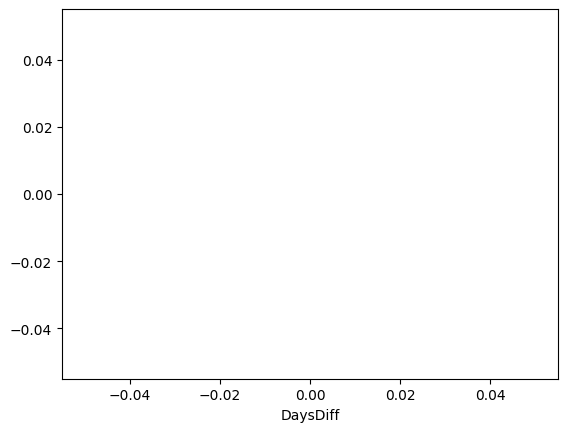

In [86]:
df_equals_different_day.groupby("DaysDiff").count()["distance"].iloc[:10].plot()

<Axes: xlabel='DaysDiff'>

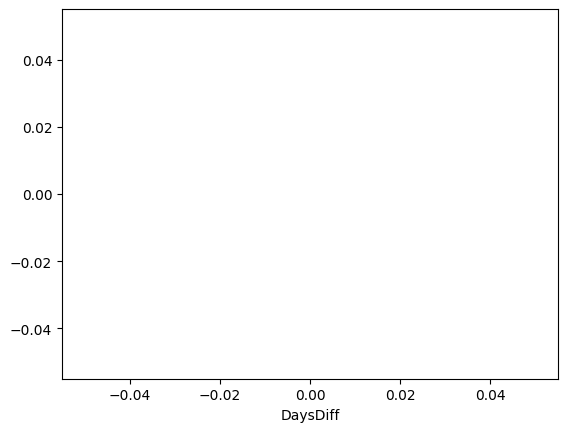

In [87]:
df_equals_different_day.groupby("DaysDiff").count()["distance"].iloc[10:].plot()

In [88]:
# Still all are visible
# pd.concat((df_close_neighbours["minFCAKey"], df_close_neighbours["maxFCAKey"]))

In [89]:
vals, amounts = np.unique(round(df_close_neighbours.distance * 2) / 2, return_counts=True)

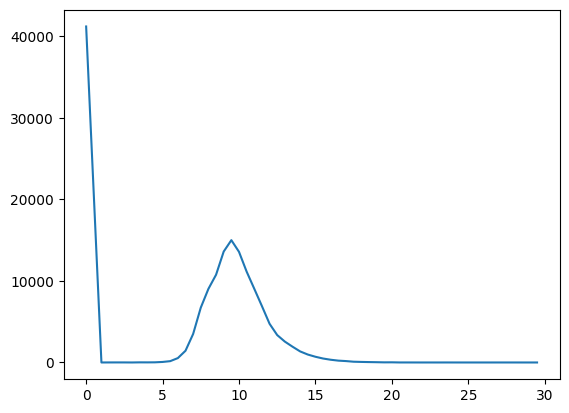

In [90]:
# Avg distance to closest neighbour, time irrelevant
plt.plot(vals, amounts)

In [92]:
vals, amounts = np.unique(round(df_close_neighbours[df_close_neighbours.distance > 0].distance * 2) / 2, return_counts=True)

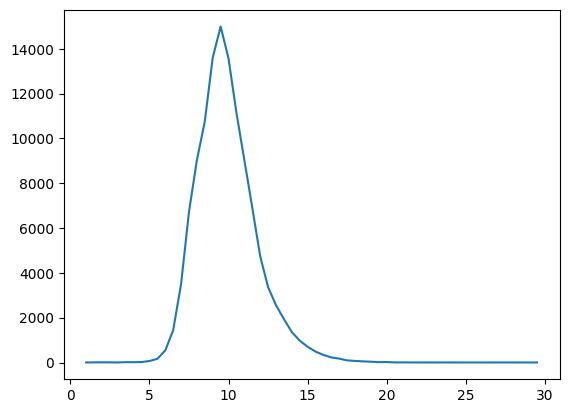

In [93]:
plt.plot(vals, amounts)

In [99]:
vals, amounts = np.unique(round(df_close_neighbours[(df_close_neighbours.distance > 0) & (df_close_neighbours.distance < 5)].distance * 2) / 2, return_counts=True)

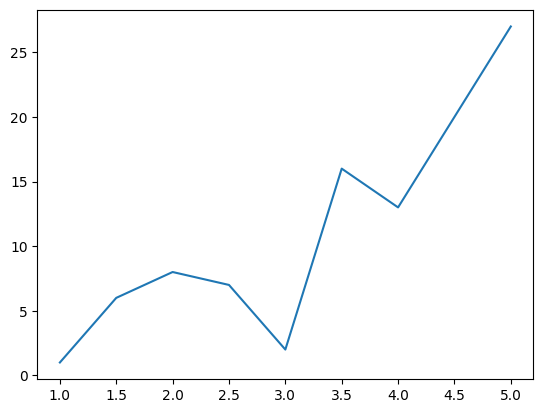

In [100]:
plt.plot(vals, amounts)